# 🦸 Welcome to the CNN Superhero Hall of Fame!

Every superhero universe has its legends — the ones who came first, the ones who changed everything, and the ones who are just *ridiculously* powerful. CNN architectures are no different!

In this notebook, you'll meet **four legendary architectures**, each one a superhero with an origin story, a superpower, and a weakness.

| 🦸 Superhero | Real Name | Year | Superpower |
|---|---|---|---|
| **The Original** (Captain America) | LeNet-5 | 1998 | First CNN that actually worked! |
| **The Game Changer** (Iron Man) | AlexNet | 2012 | Brought the deep learning tech revolution |
| **The Simple Giant** (Hulk) | VGGNet | 2014 | Just stacks layers — SMASH! |
| **The Genius** (Spider-Man) | ResNet | 2015 | Uses clever shortcuts to go impossibly deep |

## 🎯 What You'll Learn

By the end of this notebook, you'll understand:
- **LeNet-5**: The pioneer that proved CNNs could work (the first Avenger!)
- **AlexNet**: The revolution — ReLU, Dropout, GPUs, oh my!
- **VGGNet**: Going deeper with one simple trick (3×3 filters everywhere)
- **ResNet**: Skip connections that let you build networks 150 layers deep
- How to implement simplified versions of each
- When to pick which architecture (choose your fighter!)
- How to count parameters and understand computational costs

**Prerequisites:** Notebooks 1–4 (CNN basics, convolutions, pooling, complete CNN)

---

## 📖 Jargon Buster

Here's your cheat sheet. Bookmark this — you'll need it!

| Term | Kid-Friendly Explanation |
|------|--------------------------|
| **ImageNet** | A MASSIVE photo album with 1.2 million pictures in 1,000 categories — basically the Olympics for image AIs 🏅 |
| **Top-5 Error** | The AI gets 5 guesses. If the right answer isn't in any of them, it's wrong. Like a multiple-choice test where you circle 5 answers. |
| **LeNet-5** | The OG CNN (1998). Read handwritten checks at banks so humans didn't have to. |
| **AlexNet** | The CNN that made the whole world go "WHOA" in 2012. Crushed the ImageNet competition by a mile. |
| **VGGNet** | A beautifully simple CNN that just uses tiny 3×3 filters over and over (2014). Proved that going deeper = going better. |
| **ResNet** | A CNN with "skip connections" — like cheat codes that let gradients teleport through the network (2015). Beat *human-level* accuracy! |
| **Skip Connection** | A shortcut wire that lets information jump over layers. Like a secret tunnel in a maze. 🕳️ |
| **Residual** | The *difference* between what a block learned and its input. ResNet learns these tiny tweaks instead of the whole thing from scratch. |
| **Bottleneck** | A 1×1 conv that squeezes channels down, then puffs them back up. Saves a TON of computation. |
| **Batch Normalization** | Keeps each layer's outputs "well-behaved" during training — like a teacher making sure nobody's too loud or too quiet. |
| **Data Augmentation** | Creating fake training examples by flipping, rotating, or color-shifting images. Free extra data! 🎉 |
| **Dropout** | Randomly turning off neurons during training so the network can't just memorize — like studying with your notes shuffled every time. |
| **FLOPs** | Number of math operations a network needs. Measures how much your GPU has to sweat. 💦 |

---

## 🦸 The Superhero Analogy

Think of these architectures like the Avengers assembling, one by one:

- **LeNet-5** 🛡️: Like **Captain America** — the first superhero. Simple, honest, proved it could be done.
- **AlexNet** 🤖: Like **Iron Man** — showed up with bleeding-edge tech (GPUs! ReLU! Dropout!) and changed the game forever.
- **VGGNet** 💪: Like the **Hulk** — no fancy tricks, just STACKS raw power (layers). Simple but HUGE.
- **ResNet** 🕷️: Like **Spider-Man** — the genius kid who uses clever shortcuts (skip connections) to do what nobody thought was possible.

Each one taught the world something new about building neural networks. Let's meet them! 🎬

In [1]:
# Import our tools
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyBboxPatch, FancyArrowPatch
import matplotlib.patches as mpatches

# For nice plots
plt.style.use('seaborn-v0_8-darkgrid')
np.random.seed(42)

print("✅ Libraries imported successfully!")
print("📦 NumPy version:", np.__version__)

✅ Libraries imported successfully!
📦 NumPy version: 1.26.4


---
## 📅 The Superhero Timeline — Origin Stories! 🦸‍♂️

Every superhero universe has a timeline. Here's how our CNN legends appeared, one by one, each more powerful than the last — like a comic book saga!

```
🛡️ 1998: LeNet-5     → The First Avenger awakens (handwritten digits!)
            ↓ 14 years of silence... the world wasn't ready...
🤖 2012: AlexNet     → BOOM! Iron Man arrives! Deep learning revolution!
            ↓ 2 years
💪 2014: VGGNet      → The Hulk shows up — deeper, STRONGER
            ↓ 1 year  
🕷️ 2015: ResNet      → Spider-Man swings in with genius skip connections
            ↓
🚀 2016+: Modern era → New heroes keep appearing (EfficientNet, Vision Transformers...)
```

### 🎨 The Evolution — Each Hero Levels Up!

| Year | 🦸 Superhero | Layers | Key Superpower |
|------|-------------|--------|----------------|
| 1998 | 🛡️ LeNet-5 "The Original" | 5 layers | First practical CNN — proved it's possible! |
| 2012 | 🤖 AlexNet "The Game Changer" | 8 layers | ReLU, Dropout, GPU training — tech revolution! |
| 2014 | 💪 VGGNet "The Simple Giant" | 16–19 layers | Tiny 3×3 filters stacked deep — raw power! |
| 2015 | 🕷️ ResNet "The Genius" | 50–152 layers | Skip connections — outsmarted vanishing gradients! |

### 🎮 Tell Me Like I'm 12

> Imagine a video game where each new character is stronger than the last:
> - **Level 1 (1998):** You get a basic sword (LeNet). It works, but only on easy enemies (handwritten numbers).
> - **Level 2 (2012):** You find a laser gun (AlexNet)! Suddenly you can beat WAY harder bosses (real photos!).
> - **Level 3 (2014):** You stack 16 shields on top of each other (VGGNet). More = better, right? Kinda... but you're SO heavy now. 🏋️
> - **Level 4 (2015):** You discover a *teleportation shortcut* (ResNet). Now you can carry 150 shields AND still move fast. You even beat the final boss — *actual humans*! 🏆

Let's visualize this evolution:

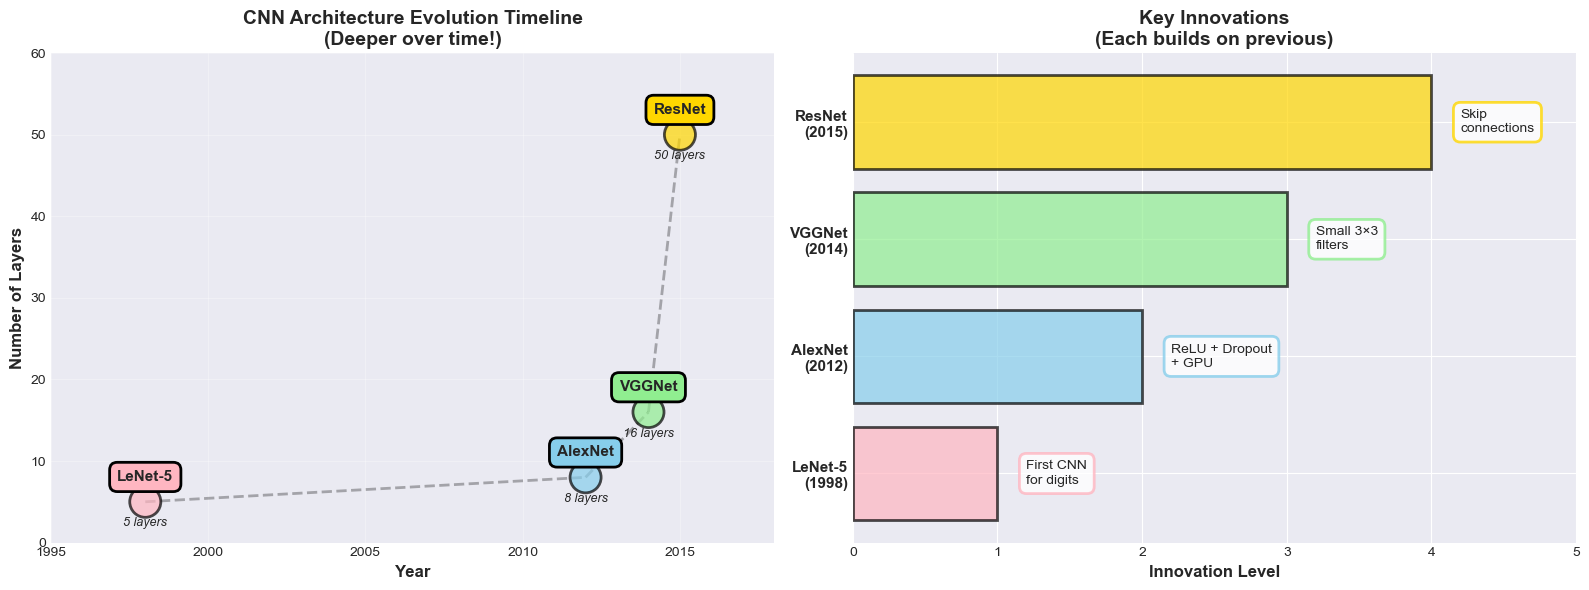


🎯 Key Insight:
   Each architecture introduced something NEW that became standard!
   Networks got deeper and more sophisticated over time.


In [2]:
# Visualize the evolution of CNN architectures
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Timeline
years = [1998, 2012, 2014, 2015]
names = ['LeNet-5', 'AlexNet', 'VGGNet', 'ResNet']
depths = [5, 8, 16, 50]
colors = ['#FFB6C1', '#87CEEB', '#90EE90', '#FFD700']

ax1.scatter(years, depths, s=500, c=colors, alpha=0.7, edgecolors='black', linewidth=2, zorder=3)

# Add connecting lines
for i in range(len(years)-1):
    ax1.plot([years[i], years[i+1]], [depths[i], depths[i+1]], 
             'k--', alpha=0.3, linewidth=2, zorder=1)

# Add labels
for year, name, depth, color in zip(years, names, depths, colors):
    ax1.annotate(name, (year, depth), 
                xytext=(0, 15), textcoords='offset points',
                ha='center', fontsize=11, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.5', facecolor=color, edgecolor='black', linewidth=2))
    ax1.text(year, depth-3, f'{depth} layers', 
            ha='center', fontsize=9, style='italic')

ax1.set_xlabel('Year', fontsize=12, fontweight='bold')
ax1.set_ylabel('Number of Layers', fontsize=12, fontweight='bold')
ax1.set_title('CNN Architecture Evolution Timeline\n(Deeper over time!)', 
             fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.set_xlim(1995, 2018)
ax1.set_ylim(0, 60)

# Plot 2: Key innovations
innovations = ['LeNet-5\n(1998)', 'AlexNet\n(2012)', 'VGGNet\n(2014)', 'ResNet\n(2015)']
key_features = [
    'First CNN\nfor digits',
    'ReLU + Dropout\n+ GPU',
    'Small 3×3\nfilters',
    'Skip\nconnections'
]

y_pos = np.arange(len(innovations))
bars = ax2.barh(y_pos, [1, 2, 3, 4], color=colors, alpha=0.7, edgecolor='black', linewidth=2)

ax2.set_yticks(y_pos)
ax2.set_yticklabels(innovations, fontsize=11, fontweight='bold')
ax2.set_xlabel('Innovation Level', fontsize=12, fontweight='bold')
ax2.set_title('Key Innovations\n(Each builds on previous)', 
             fontsize=14, fontweight='bold')
ax2.set_xlim(0, 5)

# Add innovation labels
for i, (bar, feature) in enumerate(zip(bars, key_features)):
    width = bar.get_width()
    ax2.text(width + 0.2, bar.get_y() + bar.get_height()/2,
            feature, ha='left', va='center', fontsize=10,
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white', 
                     edgecolor=colors[i], linewidth=2, alpha=0.8))

plt.tight_layout()
plt.show()

print("\n🎯 Key Insight:")
print("   Each architecture introduced something NEW that became standard!")
print("   Networks got deeper and more sophisticated over time.")

---
## 🛡️ Superhero #1: LeNet-5 — The Original! (1998)

*"I can do this all day."* — Captain America (and LeNet, reading bank checks)

### 📖 Origin Story

**Creator**: Yann LeCun (now Chief AI Scientist at Meta — yes, THAT Meta!)

**The Mission**: Banks needed to read handwritten numbers on checks. Humans were too slow. Could a neural network do it?

**Spoiler**: YES. LeNet-5 was the first CNN that actually worked on a real-world problem. It read millions of checks and proved that convolutional neural networks weren't just a cool idea — they were *useful*.

### 🏗️ Architecture Blueprint

LeNet-5 is beautifully simple — like a starter Pokémon. Small but mighty!

```
Input (32×32×1 grayscale image)
    ↓
Conv1: 6 filters, 5×5 → Output: 28×28×6
    ↓
AvgPool: 2×2 → Output: 14×14×6
    ↓
Conv2: 16 filters, 5×5 → Output: 10×10×16
    ↓
AvgPool: 2×2 → Output: 5×5×16
    ↓
Flatten → 400 neurons
    ↓
FC1: 120 neurons
    ↓
FC2: 84 neurons
    ↓
Output: 10 classes (digits 0-9)
```

### 💪 Superpowers

- ✅ **Tiny**: Only ~60,000 parameters (fits on a potato 🥔)
- ✅ **Simple**: You can understand the whole thing in 5 minutes
- ✅ **Effective**: ~99% accuracy on MNIST — nails handwritten digits
- ✅ **The Pioneer**: Proved the Conv → Pool → Conv → Pool pattern works

### 😅 Weaknesses

- ❌ **Shallow**: Only 5 layers — can't handle complex images
- ❌ **Old activation**: Used tanh instead of ReLU (slower to train)
- ❌ **Small input**: Only works with tiny 32×32 grayscale images

### 🎯 Interview Alert!

> **Q: Describe the LeNet-5 architecture. What was its historical significance?**
>
> **A:** LeNet-5 (Yann LeCun, 1998) was the first successful CNN applied to a real-world task — reading handwritten digits on bank checks. It has 5 learnable layers: 2 convolutional layers (5×5 filters) each followed by average pooling, then 3 fully connected layers. It takes 32×32 grayscale images and outputs 10 digit classes. With only ~60K parameters, it established the fundamental Conv → Pool → FC pattern that all modern CNNs build upon. It used tanh activation (ReLU hadn't been popularized yet).

### 🎮 Tell Me Like I'm 12

> Imagine you're sorting mail at the post office 📬. You need to read the ZIP code on every letter — but there are MILLIONS of letters!
>
> LeNet is like a tiny robot helper that looks at each number, squints at it through special glasses (convolution filters), makes it smaller to focus on the important parts (pooling), and then says "That's a 7!" It's small, it's simple, and it gets it right 99% of the time. Not bad for 1998! 🤖

In [3]:
# Let's implement a simplified LeNet-5!

class LeNet5:
    """
    Simplified LeNet-5 implementation.
    
    The original LeNet-5 architecture (1998) by Yann LeCun.
    Used for handwritten digit recognition.
    """
    
    def __init__(self):
        """Initialize LeNet-5 architecture parameters."""
        print("🏗️  Building LeNet-5 Architecture...")
        print("="*60)
        
        # Conv Layer 1: 1 input channel → 6 filters, 5×5
        self.conv1_filters = 6
        self.conv1_size = 5
        self.conv1_params = self.conv1_filters * self.conv1_size * self.conv1_size * 1  # 1 input channel
        print(f"Conv1: 6 filters (5×5) → {self.conv1_params} weights")
        
        # Pooling Layer 1: 2×2 average pooling
        print("Pool1: 2×2 average pooling → 0 parameters")
        
        # Conv Layer 2: 6 input channels → 16 filters, 5×5
        self.conv2_filters = 16
        self.conv2_size = 5
        self.conv2_params = self.conv2_filters * self.conv2_size * self.conv2_size * self.conv1_filters
        print(f"Conv2: 16 filters (5×5×6) → {self.conv2_params} weights")
        
        # Pooling Layer 2: 2×2 average pooling
        print("Pool2: 2×2 average pooling → 0 parameters")
        
        # Fully Connected Layers
        self.fc1_neurons = 120
        self.fc1_params = 400 * self.fc1_neurons  # 5×5×16 = 400 input features
        print(f"FC1: 400 → 120 neurons → {self.fc1_params} weights")
        
        self.fc2_neurons = 84
        self.fc2_params = self.fc1_neurons * self.fc2_neurons
        print(f"FC2: 120 → 84 neurons → {self.fc2_params} weights")
        
        self.output_neurons = 10
        self.output_params = self.fc2_neurons * self.output_neurons
        print(f"Output: 84 → 10 neurons → {self.output_params} weights")
        
        # Calculate total parameters
        self.total_params = (self.conv1_params + self.conv2_params + 
                            self.fc1_params + self.fc2_params + self.output_params)
        
        # Add biases (one per neuron/filter)
        total_biases = (self.conv1_filters + self.conv2_filters + 
                       self.fc1_neurons + self.fc2_neurons + self.output_neurons)
        self.total_params += total_biases
        
        print("="*60)
        print(f"📊 Total Parameters: {self.total_params:,}")
        print("="*60)
    
    def get_architecture_info(self):
        """Return detailed architecture information."""
        return {
            'name': 'LeNet-5',
            'year': 1998,
            'inventor': 'Yann LeCun',
            'depth': 5,
            'parameters': self.total_params,
            'input_size': '32×32×1',
            'output_classes': 10
        }

# Create a LeNet-5 model
lenet = LeNet5()
info = lenet.get_architecture_info()

print("\n📋 Architecture Summary:")
print(f"   Name: {info['name']}")
print(f"   Year: {info['year']}")
print(f"   Inventor: {info['inventor']}")
print(f"   Depth: {info['depth']} layers")
print(f"   Parameters: {info['parameters']:,}")
print(f"   Input: {info['input_size']} (grayscale)")
print(f"   Output: {info['output_classes']} classes")

🏗️  Building LeNet-5 Architecture...
Conv1: 6 filters (5×5) → 150 weights
Pool1: 2×2 average pooling → 0 parameters
Conv2: 16 filters (5×5×6) → 2400 weights
Pool2: 2×2 average pooling → 0 parameters
FC1: 400 → 120 neurons → 48000 weights
FC2: 120 → 84 neurons → 10080 weights
Output: 84 → 10 neurons → 840 weights
📊 Total Parameters: 61,706

📋 Architecture Summary:
   Name: LeNet-5
   Year: 1998
   Inventor: Yann LeCun
   Depth: 5 layers
   Parameters: 61,706
   Input: 32×32×1 (grayscale)
   Output: 10 classes


### 🗺️ LeNet's Blueprint! Time to See What's Under the Hood

/var/folders/98/5zng120j50n14r9zjqftvvq00000gn/T/ipykernel_33513/2306180128.py:69: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.tight_layout()
/opt/anaconda3/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


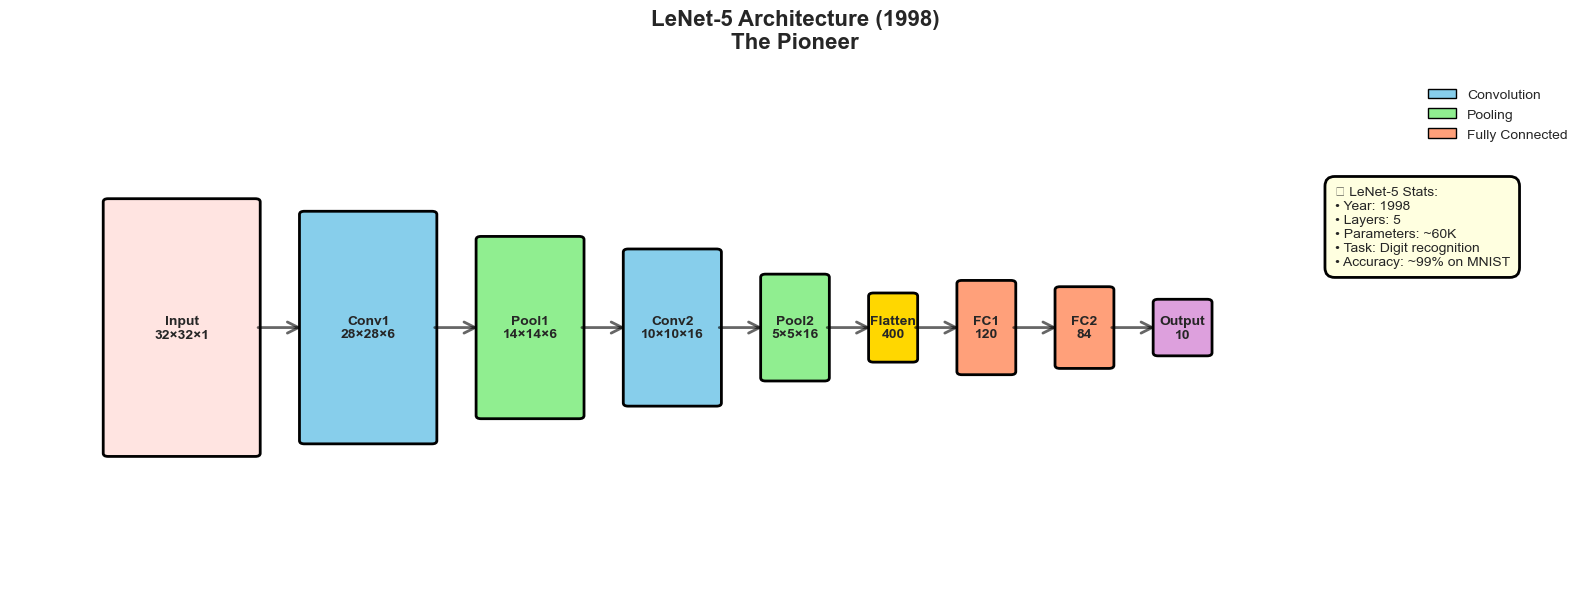


💡 Key Observations:
   • Feature maps get SMALLER (spatial dimensions decrease)
   • Feature maps get DEEPER (more channels)
   • Alternates: Conv → Pool → Conv → Pool
   • Ends with fully connected layers for classification


In [4]:
def visualize_lenet5():
    """Create a detailed visualization of LeNet-5 architecture."""
    
    fig, ax = plt.subplots(figsize=(16, 6))
    ax.set_xlim(0, 16)
    ax.set_ylim(0, 8)
    ax.axis('off')
    ax.set_title('LeNet-5 Architecture (1998)\nThe Pioneer', 
                fontsize=16, fontweight='bold', pad=20)
    
    # Define layer positions and sizes
    layers = [
        {'name': 'Input\n32×32×1', 'x': 1, 'y': 2, 'width': 1.5, 'height': 4, 'color': '#FFE4E1'},
        {'name': 'Conv1\n28×28×6', 'x': 3, 'y': 2.2, 'width': 1.3, 'height': 3.6, 'color': '#87CEEB'},
        {'name': 'Pool1\n14×14×6', 'x': 4.8, 'y': 2.6, 'width': 1.0, 'height': 2.8, 'color': '#90EE90'},
        {'name': 'Conv2\n10×10×16', 'x': 6.3, 'y': 2.8, 'width': 0.9, 'height': 2.4, 'color': '#87CEEB'},
        {'name': 'Pool2\n5×5×16', 'x': 7.7, 'y': 3.2, 'width': 0.6, 'height': 1.6, 'color': '#90EE90'},
        {'name': 'Flatten\n400', 'x': 8.8, 'y': 3.5, 'width': 0.4, 'height': 1.0, 'color': '#FFD700'},
        {'name': 'FC1\n120', 'x': 9.7, 'y': 3.3, 'width': 0.5, 'height': 1.4, 'color': '#FFA07A'},
        {'name': 'FC2\n84', 'x': 10.7, 'y': 3.4, 'width': 0.5, 'height': 1.2, 'color': '#FFA07A'},
        {'name': 'Output\n10', 'x': 11.7, 'y': 3.6, 'width': 0.5, 'height': 0.8, 'color': '#DDA0DD'}
    ]
    
    # Draw layers
    for i, layer in enumerate(layers):
        # Draw rectangle
        rect = FancyBboxPatch((layer['x'], layer['y']), layer['width'], layer['height'],
                             boxstyle="round,pad=0.05", 
                             facecolor=layer['color'], 
                             edgecolor='black', linewidth=2)
        ax.add_patch(rect)
        
        # Add label
        ax.text(layer['x'] + layer['width']/2, layer['y'] + layer['height']/2,
               layer['name'], ha='center', va='center', 
               fontsize=10, fontweight='bold')
        
        # Draw arrows between layers
        if i < len(layers) - 1:
            next_layer = layers[i + 1]
            arrow = FancyArrowPatch(
                (layer['x'] + layer['width'], layer['y'] + layer['height']/2),
                (next_layer['x'], next_layer['y'] + next_layer['height']/2),
                arrowstyle='->', mutation_scale=20, linewidth=2,
                color='black', alpha=0.6
            )
            ax.add_patch(arrow)
    
    # Add legend
    legend_elements = [
        mpatches.Patch(facecolor='#87CEEB', edgecolor='black', label='Convolution'),
        mpatches.Patch(facecolor='#90EE90', edgecolor='black', label='Pooling'),
        mpatches.Patch(facecolor='#FFA07A', edgecolor='black', label='Fully Connected'),
    ]
    ax.legend(handles=legend_elements, loc='upper right', fontsize=10)
    
    # Add key statistics
    stats_text = """📊 LeNet-5 Stats:
• Year: 1998
• Layers: 5
• Parameters: ~60K
• Task: Digit recognition
• Accuracy: ~99% on MNIST"""
    
    ax.text(13.5, 5, stats_text, fontsize=10,
           bbox=dict(boxstyle='round,pad=0.7', facecolor='lightyellow', 
                    edgecolor='black', linewidth=2))
    
    plt.tight_layout()
    plt.show()

# Visualize
visualize_lenet5()

print("\n💡 Key Observations:")
print("   • Feature maps get SMALLER (spatial dimensions decrease)")
print("   • Feature maps get DEEPER (more channels)")
print("   • Alternates: Conv → Pool → Conv → Pool")
print("   • Ends with fully connected layers for classification")

### 🛡️ LeNet's Strengths & Weaknesses (Every Superhero Has Both!)

Even Captain America has limits. Here's when LeNet shines — and when it doesn't.

**✅ LeNet's Superpowers (Good For):**
- Simple image tasks (small images, few classes) — it's FAST
- Quick prototyping — spin one up in minutes
- Learning how CNNs work — the perfect "first CNN" to study
- Resource-constrained environments (tiny devices, embedded systems)
- MNIST, Fashion-MNIST, simple digit/letter recognition

**❌ LeNet's Kryptonite (Not Good For):**
- Complex images (like ImageNet's 1000 categories of real-world photos)
- High-resolution images (it only takes 32×32 — that's TINY)
- Tasks requiring deep feature hierarchies (it's just 5 layers!)

**🏆 Historical Importance:**

LeNet-5 was the proof of concept. Without it, nobody would have believed CNNs could work. Every superhero that comes after stands on LeNet's shoulders. It's the reason AlexNet, VGGNet, and ResNet exist.

*Respect the OG.* 🫡

---
## 🤖 Superhero #2: AlexNet — The Game Changer! (2012)

*"I am Iron Man."* — Tony Stark (and AlexNet, dropping the mic at ImageNet 2012)

### 📖 Origin Story

**The Heroes**: Alex Krizhevsky, Ilya Sutskever, and Geoffrey Hinton (University of Toronto)

**The Scene**: It's 2012. The ImageNet competition is the Super Bowl of computer vision. The best traditional methods get ~26% top-5 error. Then these three heroes show up with a GPU-powered CNN and absolutely *demolish* the competition: **15.3% error**. That's not winning — that's winning by a LANDSLIDE. 🏔️

**The Aftermath**: The entire AI field collectively lost its mind. "Wait... deep learning actually WORKS?!" Papers, startups, and billion-dollar investments followed. This was the Big Bang of modern AI. 🎆

### 🏗️ Architecture Design

AlexNet is LeNet on *steroids*. Way bigger, way meaner.

```
Input (227×227×3 color image)
    ↓
Conv1: 96 filters, 11×11, stride 4 → 55×55×96
    ↓
MaxPool: 3×3, stride 2 → 27×27×96
    ↓
Conv2: 256 filters, 5×5 → 27×27×256
    ↓
MaxPool: 3×3, stride 2 → 13×13×256
    ↓
Conv3: 384 filters, 3×3 → 13×13×384
    ↓
Conv4: 384 filters, 3×3 → 13×13×384
    ↓
Conv5: 256 filters, 3×3 → 13×13×256
    ↓
MaxPool: 3×3, stride 2 → 6×6×256
    ↓
Flatten → 9216 neurons
    ↓
FC1: 4096 neurons + Dropout
    ↓
FC2: 4096 neurons + Dropout
    ↓
Output: 1000 classes (ImageNet)
```

### 💪 Revolutionary Superpowers

- ✅ **ReLU Activation**: First major CNN to use ReLU — **6x faster** training than tanh! (Just `max(0, x)`. So simple. So effective.)
- ✅ **Dropout**: Randomly turns off 50% of neurons during training. Forces the network to not memorize — like studying without your notes!
- ✅ **GPU Training**: Used 2 GPUs in parallel (revolutionary at the time! Nobody was doing this.)
- ✅ **Data Augmentation**: Random crops, flips, color jittering — free extra training data!
- ✅ **Local Response Normalization**: Helped with generalization (later replaced by Batch Norm)

### 📊 Size Comparison: LeNet vs. AlexNet

| Metric | 🛡️ LeNet-5 | 🤖 AlexNet |
|--------|---------|----------|
| Parameters | ~60K | ~60M (**1000x more!**) |
| Layers | 5 | 8 |
| Input Size | 32×32 | 227×227 |
| Filters (first layer) | 6 | 96 |
| Task | 10 digits | 1000 categories |

### 🎯 Interview Alert!

> **Q: What were AlexNet's key innovations? Why was it so important for deep learning?**
>
> **A:** AlexNet (Krizhevsky, Sutskever, Hinton, 2012) won ImageNet with 15.3% top-5 error, crushing the runner-up at 26.2%. Its key innovations were: (1) **ReLU activation** — 6x faster training than tanh/sigmoid, solving the vanishing gradient issue for shallow-to-medium networks; (2) **Dropout regularization** (p=0.5) — prevents overfitting by randomly zeroing neurons during training; (3) **GPU training** — split the network across 2 GPUs for parallel computation; (4) **Data augmentation** — random crops, flips, and color jittering to increase effective dataset size. AlexNet sparked the modern deep learning revolution and made CNNs the dominant approach in computer vision.

### 🎮 Tell Me Like I'm 12

> **ReLU** is like a bouncer at a club 🚪: if a number is positive, it gets in. If it's negative, NOPE — it becomes zero. Simple rule, but it makes training WAY faster than the old complicated rules (tanh/sigmoid).
>
> **Dropout** is like a teacher who randomly picks half the students to sit out during practice 🏀. The remaining students HAVE to learn to play without relying on the stars. When game day comes (test time), everyone plays — and the team is stronger because everyone learned independently!
>
> AlexNet combined these tricks with raw GPU power and CRUSHED the competition. It's like showing up to a bike race with a motorcycle. 🏍️💨

In [5]:
# Let's implement a simplified AlexNet!

class AlexNet:
    """
    Simplified AlexNet implementation.
    
    The architecture that won ImageNet 2012 and started the deep learning revolution.
    """
    
    def __init__(self):
        """Initialize AlexNet architecture parameters."""
        print("🚀 Building AlexNet Architecture...")
        print("="*60)
        
        # Convolutional layers
        self.conv1 = {'filters': 96, 'size': 11, 'stride': 4}  # 227→55
        print(f"Conv1: 96 filters (11×11, stride 4) → Large filters!")
        
        self.conv2 = {'filters': 256, 'size': 5, 'stride': 1}  # 27→27
        print(f"Conv2: 256 filters (5×5) → More channels")
        
        self.conv3 = {'filters': 384, 'size': 3, 'stride': 1}  # 13→13
        print(f"Conv3: 384 filters (3×3) → Getting deeper")
        
        self.conv4 = {'filters': 384, 'size': 3, 'stride': 1}  # 13→13
        print(f"Conv4: 384 filters (3×3) → More processing")
        
        self.conv5 = {'filters': 256, 'size': 3, 'stride': 1}  # 13→13
        print(f"Conv5: 256 filters (3×3) → Final conv layer")
        
        # Fully connected layers
        self.fc1_neurons = 4096
        print(f"FC1: 9216 → 4096 neurons + Dropout(0.5)")
        
        self.fc2_neurons = 4096
        print(f"FC2: 4096 → 4096 neurons + Dropout(0.5)")
        
        self.output_neurons = 1000  # ImageNet classes
        print(f"Output: 4096 → 1000 classes (ImageNet)")
        
        # Calculate parameters (simplified)
        # Conv layers: filters × size × size × input_channels
        conv1_params = 96 * 11 * 11 * 3  # RGB input
        conv2_params = 256 * 5 * 5 * 96
        conv3_params = 384 * 3 * 3 * 256
        conv4_params = 384 * 3 * 3 * 384
        conv5_params = 256 * 3 * 3 * 384
        
        # FC layers
        fc1_params = 9216 * 4096  # 6×6×256 = 9216
        fc2_params = 4096 * 4096
        output_params = 4096 * 1000
        
        self.total_params = (conv1_params + conv2_params + conv3_params + 
                            conv4_params + conv5_params + fc1_params + 
                            fc2_params + output_params)
        
        print("="*60)
        print(f"📊 Total Parameters: {self.total_params:,}")
        print(f"📊 That's {self.total_params / 1_000_000:.1f} million parameters!")
        print("="*60)
    
    def get_architecture_info(self):
        """Return detailed architecture information."""
        return {
            'name': 'AlexNet',
            'year': 2012,
            'inventors': 'Krizhevsky, Sutskever, Hinton',
            'depth': 8,
            'parameters': self.total_params,
            'input_size': '227×227×3',
            'output_classes': 1000,
            'key_innovations': ['ReLU', 'Dropout', 'GPU Training', 'Data Augmentation']
        }

# Create AlexNet model
alexnet = AlexNet()
info = alexnet.get_architecture_info()

print("\n🎯 Key Innovations:")
for innovation in info['key_innovations']:
    print(f"   • {innovation}")

print("\n💪 Impact:")
print("   • Won ImageNet 2012 by a HUGE margin")
print("   • Proved deep learning could work at scale")
print("   • Sparked the modern AI revolution")
print("   • Made ReLU and Dropout standard techniques")

🚀 Building AlexNet Architecture...
Conv1: 96 filters (11×11, stride 4) → Large filters!
Conv2: 256 filters (5×5) → More channels
Conv3: 384 filters (3×3) → Getting deeper
Conv4: 384 filters (3×3) → More processing
Conv5: 256 filters (3×3) → Final conv layer
FC1: 9216 → 4096 neurons + Dropout(0.5)
FC2: 4096 → 4096 neurons + Dropout(0.5)
Output: 4096 → 1000 classes (ImageNet)
📊 Total Parameters: 62,367,776
📊 That's 62.4 million parameters!

🎯 Key Innovations:
   • ReLU
   • Dropout
   • GPU Training
   • Data Augmentation

💪 Impact:
   • Won ImageNet 2012 by a HUGE margin
   • Proved deep learning could work at scale
   • Sparked the modern AI revolution
   • Made ReLU and Dropout standard techniques


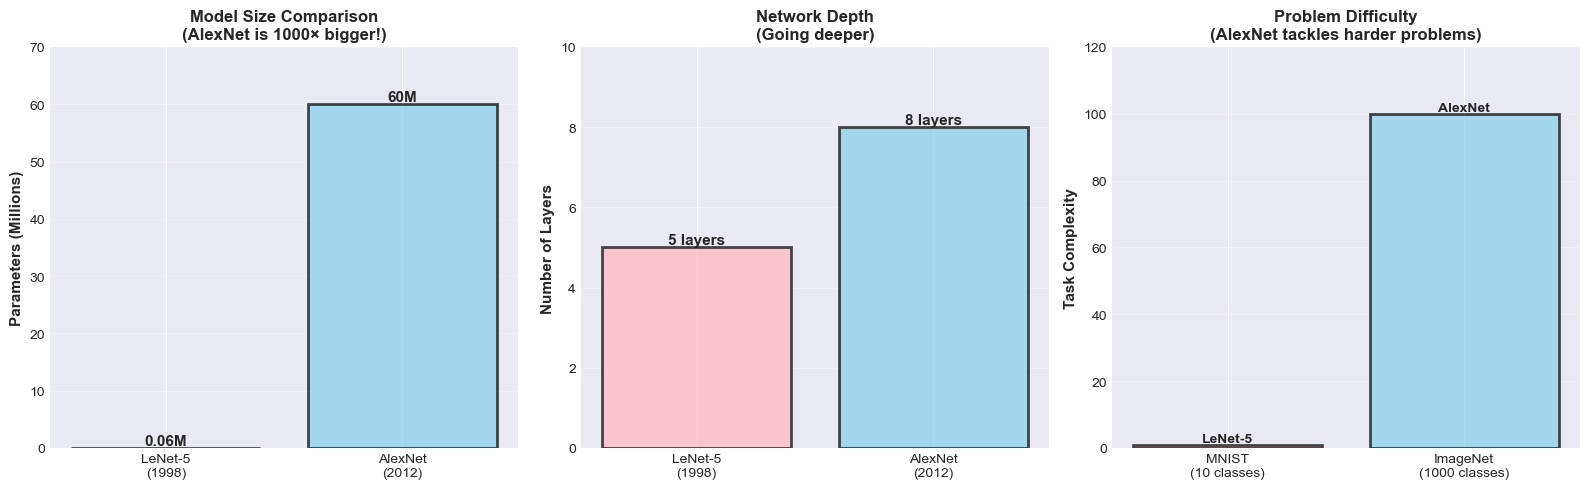


📈 The Evolution from LeNet to AlexNet:
   1. 1000× more parameters → Can learn much more complex features
   2. Deeper network → Better feature hierarchies
   3. New techniques (ReLU, Dropout) → Better training
   4. GPU power → Can train on huge datasets (ImageNet)

💡 Key Lesson: Sometimes BIGGER really is BETTER!


In [6]:
# Compare LeNet-5 and AlexNet

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 5))

# Comparison data
models = ['LeNet-5\n(1998)', 'AlexNet\n(2012)']
params = [0.06, 60]  # in millions
layers = [5, 8]
accuracy = [99, 84]  # MNIST vs ImageNet top-5

# Plot 1: Parameters comparison
bars1 = ax1.bar(models, params, color=['#FFB6C1', '#87CEEB'], 
               edgecolor='black', linewidth=2, alpha=0.7)
ax1.set_ylabel('Parameters (Millions)', fontsize=11, fontweight='bold')
ax1.set_title('Model Size Comparison\n(AlexNet is 1000× bigger!)', 
             fontsize=12, fontweight='bold')
ax1.set_ylim(0, 70)
ax1.grid(axis='y', alpha=0.3)

# Add value labels
for bar, val in zip(bars1, params):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.2f}M' if val < 1 else f'{val:.0f}M',
            ha='center', va='bottom', fontweight='bold', fontsize=11)

# Plot 2: Depth comparison
bars2 = ax2.bar(models, layers, color=['#FFB6C1', '#87CEEB'],
               edgecolor='black', linewidth=2, alpha=0.7)
ax2.set_ylabel('Number of Layers', fontsize=11, fontweight='bold')
ax2.set_title('Network Depth\n(Going deeper)', 
             fontsize=12, fontweight='bold')
ax2.set_ylim(0, 10)
ax2.grid(axis='y', alpha=0.3)

for bar, val in zip(bars2, layers):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{val} layers',
            ha='center', va='bottom', fontweight='bold', fontsize=11)

# Plot 3: Task difficulty
tasks = ['MNIST\n(10 classes)', 'ImageNet\n(1000 classes)']
difficulty = [1, 100]  # Relative difficulty
bars3 = ax3.bar(tasks, difficulty, color=['#FFB6C1', '#87CEEB'],
               edgecolor='black', linewidth=2, alpha=0.7)
ax3.set_ylabel('Task Complexity', fontsize=11, fontweight='bold')
ax3.set_title('Problem Difficulty\n(AlexNet tackles harder problems)', 
             fontsize=12, fontweight='bold')
ax3.set_ylim(0, 120)
ax3.grid(axis='y', alpha=0.3)

for bar, model in zip(bars3, models):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
            model.split('\n')[0],
            ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

print("\n📈 The Evolution from LeNet to AlexNet:")
print("   1. 1000× more parameters → Can learn much more complex features")
print("   2. Deeper network → Better feature hierarchies")
print("   3. New techniques (ReLU, Dropout) → Better training")
print("   4. GPU power → Can train on huge datasets (ImageNet)")
print("\n💡 Key Lesson: Sometimes BIGGER really is BETTER!")

## 💪 Superhero #3: VGGNet — The Simple Giant! (2014)

*"HULK SMASH!"* — Hulk (and VGGNet, stacking 3×3 filters 16 layers deep)

### 📖 Origin Story

**Creators**: The Visual Geometry Group at Oxford University (that's where "VGG" comes from!)

**Philosophy**: "Why use fancy tricks when you can just... go DEEPER?" 🏋️

**Impact**: Showed the entire world that depth matters more than clever architecture tricks. Sometimes brute force (with a smart twist) wins.

### 🏗️ Architecture Design

VGGNet has the most **beautifully uniform** design of any CNN. It's like IKEA furniture — simple, repeatable modules.

**VGG-16 Architecture** (16 weight layers):

```
Input (224×224×3)
    ↓
Block 1:
  Conv 3×3, 64 filters → 224×224×64
  Conv 3×3, 64 filters → 224×224×64
  MaxPool 2×2 → 112×112×64
    ↓
Block 2:
  Conv 3×3, 128 filters → 112×112×128
  Conv 3×3, 128 filters → 112×112×128
  MaxPool 2×2 → 56×56×128
    ↓
Block 3:
  Conv 3×3, 256 filters → 56×56×256
  Conv 3×3, 256 filters → 56×56×256
  Conv 3×3, 256 filters → 56×56×256
  MaxPool 2×2 → 28×28×256
    ↓
Block 4:
  Conv 3×3, 512 filters → 28×28×512
  Conv 3×3, 512 filters → 28×28×512
  Conv 3×3, 512 filters → 28×28×512
  MaxPool 2×2 → 14×14×512
    ↓
Block 5:
  Conv 3×3, 512 filters → 14×14×512
  Conv 3×3, 512 filters → 14×14×512
  Conv 3×3, 512 filters → 14×14×512
  MaxPool 2×2 → 7×7×512
    ↓
FC: 4096 → 4096 → 1000
```

### 💡 The 3×3 Filter Philosophy (THIS IS THE KEY INSIGHT!)

**The Big Idea**: Two 3×3 convolutions see the **same area** as one 5×5 — but with **fewer parameters** and **more non-linearity**!

```
Option 1: One 5×5 filter
  Parameters: 5×5 = 25 per filter
  Non-linearity: 1 ReLU
  
Option 2: Two 3×3 filters (VGG's choice! ✅)
  Parameters: 3×3 + 3×3 = 18 per filter stack
  Non-linearity: 2 ReLUs
  
Savings: 28% fewer parameters + 2× more non-linearity! 🎉
```

And it gets even better — **three** 3×3 convolutions replace one 7×7:
```
Three 3×3 filters: 3×(3×3) = 27 params → replaces one 7×7 = 49 params
That's a 45% savings! Plus 3 ReLUs instead of 1!
```

### 🎯 VGG Design Principles

- ✅ **Only 3×3 filters**: Simple, uniform, efficient
- ✅ **Deep stacking**: 2–3 conv layers before each pooling
- ✅ **Channel doubling**: 64 → 128 → 256 → 512 (doubles after each pool)
- ✅ **Spatial halving**: Each pooling cuts spatial dimensions in half
- ✅ **Same padding**: Spatial size stays constant within blocks

**The Pattern** (memorize this!):
```
Conv(3×3) → Conv(3×3) → ... → Pool(2×2) → [REPEAT with 2× channels]
```

### 🎯 Interview Alert!

> **Q: Why does VGG use only 3×3 filters? What's the advantage of stacking small filters vs. using one large filter?**
>
> **A:** VGG uses exclusively 3×3 filters because stacking them gives the same effective receptive field as larger filters, but with two advantages: (1) **Fewer parameters** — two 3×3 convs have 2×(3×3×C²) = 18C² parameters vs. one 5×5 conv with 25C² parameters (28% savings). Three 3×3 convs have 27C² vs. one 7×7 at 49C² (45% savings). (2) **More non-linearity** — each 3×3 conv is followed by a ReLU, so stacking 2 or 3 gives 2–3 ReLU activations vs. just 1 for a single large filter. More non-linearity = the network can learn more complex decision boundaries. This insight became a foundational principle: **small stacked filters beat large single filters**.

### 🎮 Tell Me Like I'm 12

> Think about LEGO bricks 🧱. You COULD build a wall with one giant brick. But it's WAY better to use lots of small bricks because:
> 1. **Small bricks are cheaper** (fewer parameters)
> 2. **You can make cooler shapes** (more non-linearity — the network learns more complex stuff)
> 3. **They cover the same area** when you stack them!
>
> VGGNet said: "Forget big fancy filters. Just give me a MOUNTAIN of tiny 3×3 LEGO bricks and I'll build something amazing." And it did! 🏗️
>
> The downside? VGGNet has 138 MILLION parameters. That Hulk is *heavy*. 🏋️

In [7]:
# Let's implement and visualize VGG-16!

class VGG16:
    """
    VGG-16 implementation (2014).
    
    Simple, uniform architecture: only 3×3 convolutions!
    """
    
    def __init__(self):
        """Initialize VGG-16 architecture."""
        print("🏢 Building VGG-16 Architecture...")
        print("="*60)
        
        # VGG-16 uses repeating patterns of Conv blocks
        self.architecture = [
            # Block 1
            ('conv3-64', 2),   # 2 conv layers with 64 filters
            ('pool',),
            
            # Block 2
            ('conv3-128', 2),  # 2 conv layers with 128 filters
            ('pool',),
            
            # Block 3
            ('conv3-256', 3),  # 3 conv layers with 256 filters
            ('pool',),
            
            # Block 4
            ('conv3-512', 3),  # 3 conv layers with 512 filters
            ('pool',),
            
            # Block 5
            ('conv3-512', 3),  # 3 conv layers with 512 filters
            ('pool',),
            
            # Fully connected
            ('fc', 4096),
            ('fc', 4096),
            ('fc', 1000),
        ]
        
        # Calculate parameters for each block
        params_by_block = []
        
        # Conv blocks
        in_channels = 3
        spatial_size = 224
        
        print("\n📊 Layer-by-layer breakdown:")
        print("-"*60)
        
        for i, layer_config in enumerate(self.architecture):
            if layer_config[0] == 'pool':
                spatial_size //= 2
                print(f"  Pool: {spatial_size}×{spatial_size}×{in_channels} (0 params)")
                
            elif layer_config[0].startswith('conv'):
                # Extract number of filters from 'conv3-64' format
                n_filters = int(layer_config[0].split('-')[1])
                n_layers = layer_config[1]
                
                # Calculate parameters for this block
                # Each conv: 3×3×in_channels×out_channels + out_channels (bias)
                params_per_conv = (3 * 3 * in_channels * n_filters) + n_filters
                block_params = params_per_conv * n_layers
                params_by_block.append(block_params)
                
                print(f"  Conv Block: {n_layers}× [3×3×{in_channels}→{n_filters}] = {block_params:,} params")
                
                in_channels = n_filters
                
            elif layer_config[0] == 'fc':
                n_neurons = layer_config[1]
                
                if in_channels == 512:  # First FC layer (after flatten)
                    fc_input = spatial_size * spatial_size * in_channels
                    params = fc_input * n_neurons + n_neurons
                    print(f"  FC1: {fc_input}→{n_neurons} = {params:,} params")
                else:
                    params = in_channels * n_neurons + n_neurons
                    print(f"  FC: {in_channels}→{n_neurons} = {params:,} params")
                
                params_by_block.append(params)
                in_channels = n_neurons
        
        self.total_params = sum(params_by_block)
        
        print("="*60)
        print(f"📊 Total Parameters: {self.total_params:,}")
        print(f"   That's ~{self.total_params / 1_000_000:.0f} million parameters!")
        print("="*60)
    
    def get_architecture_info(self):
        """Return architecture information."""
        return {
            'name': 'VGG-16',
            'year': 2014,
            'inventors': 'Visual Geometry Group (Oxford)',
            'depth': 16,
            'parameters': self.total_params,
            'input_size': '224×224×3',
            'output_classes': 1000,
            'key_innovation': 'Uniform 3×3 filters'
        }

# Create VGG-16 model
vgg16 = VGG16()
info = vgg16.get_architecture_info()

print("\n💡 VGG's Key Innovation:")
print("   • ALL convolutions use 3×3 filters")
print("   • Stacking 3×3 filters is more efficient than larger filters")
print("   • Simple, repeatable design pattern")
print("   • Easy to implement and understand")

print("\n🎯 Why 3×3 Filters Win:")
print("   • Two 3×3 convs = same receptive field as one 5×5")
print("   • But 3×3×2 = 18 params vs 5×5 = 25 params (28% savings!)")
print("   • Plus you get 2 ReLUs instead of 1 (more non-linearity)")
print("   • Three 3×3 convs = same as one 7×7 (even more efficient!)")

🏢 Building VGG-16 Architecture...

📊 Layer-by-layer breakdown:
------------------------------------------------------------
  Conv Block: 2× [3×3×3→64] = 3,584 params
  Pool: 112×112×64 (0 params)
  Conv Block: 2× [3×3×64→128] = 147,712 params
  Pool: 56×56×128 (0 params)
  Conv Block: 3× [3×3×128→256] = 885,504 params
  Pool: 28×28×256 (0 params)
  Conv Block: 3× [3×3×256→512] = 3,540,480 params
  Pool: 14×14×512 (0 params)
  Conv Block: 3× [3×3×512→512] = 7,079,424 params
  Pool: 7×7×512 (0 params)
  FC1: 25088→4096 = 102,764,544 params
  FC: 4096→4096 = 16,781,312 params
  FC: 4096→1000 = 4,097,000 params
📊 Total Parameters: 135,299,560
   That's ~135 million parameters!

💡 VGG's Key Innovation:
   • ALL convolutions use 3×3 filters
   • Stacking 3×3 filters is more efficient than larger filters
   • Simple, repeatable design pattern
   • Easy to implement and understand

🎯 Why 3×3 Filters Win:
   • Two 3×3 convs = same receptive field as one 5×5
   • But 3×3×2 = 18 params vs 5×5 = 

/var/folders/98/5zng120j50n14r9zjqftvvq00000gn/T/ipykernel_33513/3231151393.py:65: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()
/opt/anaconda3/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


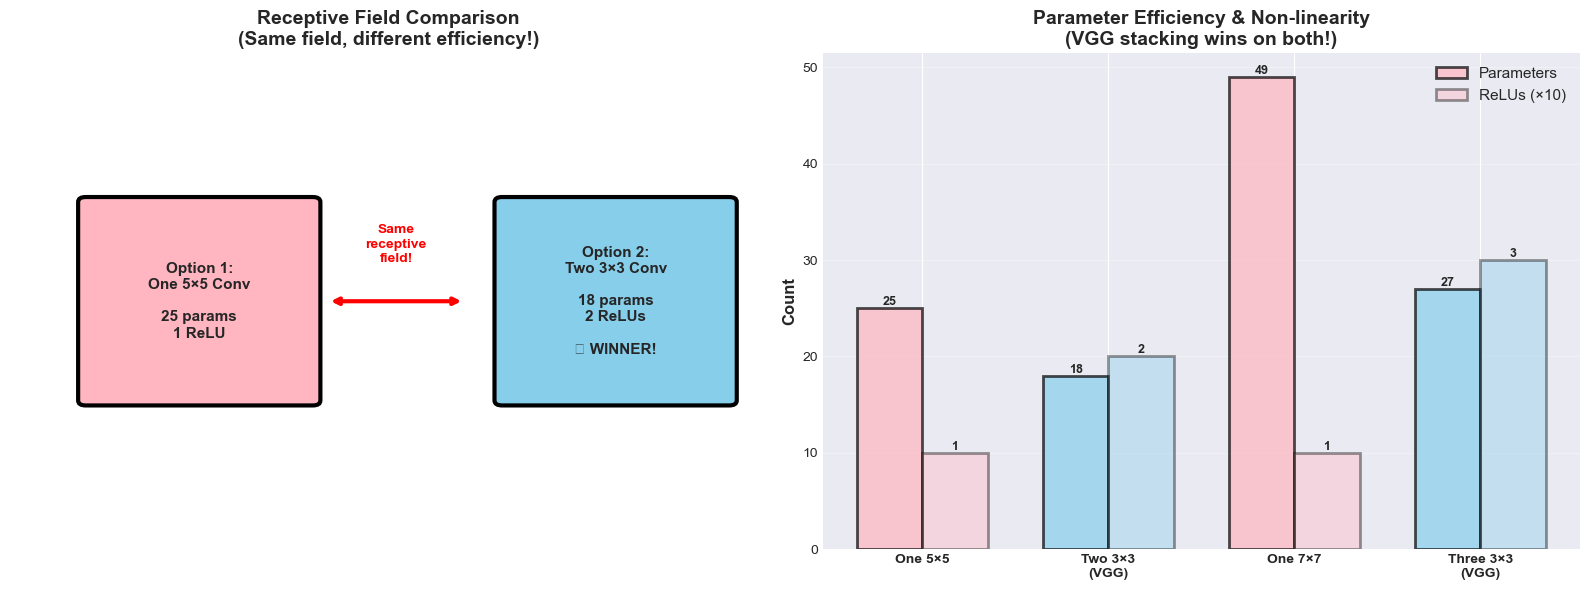


📊 The Math Behind VGG's Efficiency:
One 5×5 filter:
  • Parameters: 5 × 5 = 25
  • Receptive field: 5×5
  • Non-linearity: 1 ReLU

Two 3×3 filters (VGG's approach):
  • Parameters: (3×3) + (3×3) = 18
  • Receptive field: SAME 5×5! (second filter sees 5×5 of original)
  • Non-linearity: 2 ReLUs
  • Savings: 28% fewer parameters, 100% more non-linearity!

Three 3×3 filters:
  • Parameters: 3×3 + 3×3 + 3×3 = 27
  • Receptive field: 7×7
  • Compare to one 7×7: 49 params (45% savings!)


In [8]:
# Visualize why 3×3 filters are superior

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left plot: Receptive field comparison
ax1 = axes[0]
ax1.set_xlim(0, 10)
ax1.set_ylim(0, 10)
ax1.axis('off')
ax1.set_title('Receptive Field Comparison\n(Same field, different efficiency!)', 
             fontsize=14, fontweight='bold')

# Option 1: One 5×5
rect1 = FancyBboxPatch((1, 3), 3, 4, boxstyle="round,pad=0.1",
                      facecolor='#FFB6C1', edgecolor='black', linewidth=3)
ax1.add_patch(rect1)
ax1.text(2.5, 5, 'Option 1:\nOne 5×5 Conv\n\n25 params\n1 ReLU', 
        ha='center', va='center', fontsize=11, fontweight='bold')

# Arrow
ax1.annotate('', xy=(6, 5), xytext=(4.2, 5),
            arrowprops=dict(arrowstyle='<->', lw=3, color='red'))
ax1.text(5.1, 5.8, 'Same\nreceptive\nfield!', ha='center', fontsize=10, 
        color='red', fontweight='bold')

# Option 2: Two 3×3
rect2 = FancyBboxPatch((6.5, 3), 3, 4, boxstyle="round,pad=0.1",
                      facecolor='#87CEEB', edgecolor='black', linewidth=3)
ax1.add_patch(rect2)
ax1.text(8, 5, 'Option 2:\nTwo 3×3 Conv\n\n18 params\n2 ReLUs\n\n✅ WINNER!', 
        ha='center', va='center', fontsize=11, fontweight='bold')

# Right plot: Parameter efficiency
ax2 = axes[1]

filter_configs = ['One 5×5', 'Two 3×3\n(VGG)', 'One 7×7', 'Three 3×3\n(VGG)']
params_count = [25, 18, 49, 27]
relu_count = [1, 2, 1, 3]
colors_list = ['#FFB6C1', '#87CEEB', '#FFB6C1', '#87CEEB']

x = np.arange(len(filter_configs))
width = 0.35

bars1 = ax2.bar(x - width/2, params_count, width, label='Parameters',
               color=colors_list, alpha=0.7, edgecolor='black', linewidth=2)
bars2 = ax2.bar(x + width/2, [r*10 for r in relu_count], width, label='ReLUs (×10)',
               color=colors_list, alpha=0.4, edgecolor='black', linewidth=2)

ax2.set_ylabel('Count', fontsize=12, fontweight='bold')
ax2.set_title('Parameter Efficiency & Non-linearity\n(VGG stacking wins on both!)', 
             fontsize=14, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(filter_configs, fontsize=10, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(axis='y', alpha=0.3)

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}' if bars == bars1 else f'{int(height//10)}',
                ha='center', va='bottom', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

print("\n📊 The Math Behind VGG's Efficiency:")
print("="*60)
print("One 5×5 filter:")
print("  • Parameters: 5 × 5 = 25")
print("  • Receptive field: 5×5")
print("  • Non-linearity: 1 ReLU")
print()
print("Two 3×3 filters (VGG's approach):")
print("  • Parameters: (3×3) + (3×3) = 18")
print("  • Receptive field: SAME 5×5! (second filter sees 5×5 of original)")
print("  • Non-linearity: 2 ReLUs")
print("  • Savings: 28% fewer parameters, 100% more non-linearity!")
print()
print("Three 3×3 filters:")
print("  • Parameters: 3×3 + 3×3 + 3×3 = 27")
print("  • Receptive field: 7×7")
print("  • Compare to one 7×7: 49 params (45% savings!)")
print("="*60)

---
## 🕷️ Superhero #4: ResNet — The Genius with Shortcuts! (2015)

*"With great power comes great responsibility... and skip connections."* — Spider-Man (probably)

**This is THE most important architecture to understand for interviews. Pay attention!** 🚨

### 📖 Origin Story

**The Heroes**: Kaiming He, Xiangyu Zhang, Shaoqing Ren, Jian Sun (Microsoft Research)

**The Breakthrough**: Won ImageNet 2015 with **3.57% top-5 error** — that's **better than HUMANS** (humans score ~5%)! A machine finally outperformed the human eye on this task. 🤯

**The Secret Weapon**: **Skip connections** (a.k.a. residual connections) — a brilliantly simple idea that let networks go 152 layers deep without breaking.

### 🤔 The Problem ResNet Solved: The Vanishing Gradient Nightmare

Before ResNet, there was a HUGE mystery:

```
Deep Network (e.g., 50+ layers):
Input → Layer 1 → Layer 2 → ... → Layer 50 → Output
         ↑                                    ↓
         └────────── Backprop ←───────────────┘

Problem: Gradients get smaller and smaller as they travel back!
Result: Early layers get TINY gradients → they basically stop learning!
```

**The Shocking Discovery**: Deeper networks actually performed **WORSE** than shallow ones!

```
Plain Network Performance:
20 layers: 8.5% error  ✅ Good!
56 layers: 9.5% error  ❌ WORSE! Wait, what?!
```

This made NO sense. A 56-layer network should be *at least* as good as a 20-layer one — the extra layers could just learn to do nothing (identity mapping). But in practice, optimizing those extra layers was too hard, and the vanishing gradient problem made it even worse.

### 🎯 Interview Alert! — Vanishing Gradients

> **Q: What is the vanishing gradient problem? How does it affect deep networks?**
>
> **A:** During backpropagation, gradients are computed via the chain rule — multiplying partial derivatives layer by layer. If these derivatives are less than 1 (common with sigmoid/tanh activations), the gradient shrinks exponentially as it passes through each layer. In a 50-layer network, the gradient reaching the first layer can be astronomically small (e.g., 0.9^50 ≈ 0.005). This means early layers receive near-zero gradients and essentially stop learning. ReLU partially helped (gradient is 1 for positive inputs), but for very deep networks (>20 layers), even ReLU wasn't enough. The deeper the network, the worse this problem gets — which is why simply stacking more layers made performance *worse*, not better.

### 💡 The Solution: Skip Connections (Residual Learning)

**The Genius Insight**: Instead of forcing each block to learn the full desired mapping H(x), just learn the **residual** F(x) = H(x) - x. Then add the input back: Output = F(x) + x.

```
Traditional Block:          Residual Block:
Input (x)                   Input (x)
   ↓                           ↓ ↓
Conv+ReLU                      | Conv+ReLU
   ↓                           |    ↓
Conv                           | Conv
   ↓                           |    ↓
Output: H(x)                   └──→ + ─→ Output: F(x) + x
                                  ↑
                           Skip connection!
```

**Why This Is Brilliant**:
1. **Easy identity**: If the best thing a block can do is "nothing," it just learns F(x) = 0 (easy!). The output becomes 0 + x = x. Perfect identity!
2. **Gradient highway**: During backprop, the gradient flows DIRECTLY through the skip connection (gradient of x with respect to x = 1). No vanishing!
3. **No degradation**: Adding more layers can NEVER make things worse — at worst, they learn the identity.

### 🎯 Interview Alert! — Skip Connections

> **Q: What are skip connections / residual connections? How do they solve vanishing gradients?**
>
> **A:** Skip connections (introduced in ResNet, 2015) add the input of a block directly to its output: y = F(x) + x, where F(x) is the residual function learned by the stacked layers. This solves vanishing gradients in two ways: (1) **Gradient highway** — during backpropagation, the gradient of the identity shortcut is always 1, so gradients can flow directly to earlier layers regardless of network depth. (2) **Easier optimization** — instead of learning the full mapping H(x), the network only needs to learn the residual F(x) = H(x) - x. If identity is optimal, F(x) = 0 is easy to learn (push all weights toward zero). This is why deeper ResNets always perform at least as well as shallower ones — unlike plain networks, they can't "degrade."

### 🏗️ ResNet-50 Architecture

```
Input (224×224×3)
    ↓
Conv: 7×7, 64 filters, stride 2 → 112×112×64
MaxPool: 3×3, stride 2 → 56×56×64
    ↓
Block 1: 3× Bottleneck blocks (64 filters) → 56×56×256
    ↓
Block 2: 4× Bottleneck blocks (128 filters) → 28×28×512
    ↓
Block 3: 6× Bottleneck blocks (256 filters) → 14×14×1024
    ↓
Block 4: 3× Bottleneck blocks (512 filters) → 7×7×2048
    ↓
Global Average Pool → 2048
    ↓
FC: 1000 classes
```

### 🧱 Residual Block Types

**Basic Block** (used in ResNet-18, ResNet-34):
```
Input
  ↓ ↓
  | 3×3 Conv → BN → ReLU
  |    ↓
  | 3×3 Conv → BN
  |    ↓
  └──→ + → ReLU
       ↓
     Output
```

**Bottleneck Block** (used in ResNet-50, ResNet-101, ResNet-152):
```
Input (e.g., 256 channels)
  ↓ ↓
  | 1×1 Conv (64) → BN → ReLU  [Squeeze: reduce channels]
  |    ↓
  | 3×3 Conv (64) → BN → ReLU  [Process: the real work]
  |    ↓
  | 1×1 Conv (256) → BN        [Expand: restore channels]
  |    ↓
  └──→ + → ReLU
       ↓
     Output (256 channels)
```

### 🎯 Interview Alert! — Bottleneck Blocks & 1×1 Convolutions

> **Q: What is a bottleneck block? What is the role of 1×1 convolutions in ResNet?**
>
> **A:** A bottleneck block is a 3-layer residual block used in deeper ResNets (50+). It uses 1×1 convolutions to create a "bottleneck": (1) **1×1 conv reduces** channels (e.g., 256 → 64) — this drastically cuts the number of parameters for the next layer; (2) **3×3 conv processes** the reduced representation — this is where the spatial feature learning happens, but on fewer channels so it's cheap; (3) **1×1 conv expands** channels back (e.g., 64 → 256) — restores the original dimensionality for the skip connection addition. The 1×1 convolution acts as a learnable channel-wise linear transformation — it mixes information across channels without affecting spatial dimensions. This makes ResNet-50 computationally tractable despite having 50 layers.

### 🎯 Interview Alert! — Batch Normalization

> **Q: What is batch normalization and why is it used in ResNet?**
>
> **A:** Batch Normalization (Ioffe & Szegedy, 2015) normalizes each layer's activations to have zero mean and unit variance across the current mini-batch: x̂ = (x - μ_batch) / √(σ²_batch + ε), then applies learnable scale (γ) and shift (β) parameters: y = γx̂ + β. Benefits: (1) **Reduces internal covariate shift** — each layer's input distribution stays stable, making optimization easier; (2) **Allows higher learning rates** — normalized activations prevent gradients from exploding; (3) **Acts as mild regularization** — the batch statistics introduce noise, similar to dropout; (4) **Enables deeper networks** — combined with skip connections, BN is essential for training 50–152 layer ResNets. In ResNet, BN is applied after every convolution and before ReLU activation.

### 🎮 Tell Me Like I'm 12

> Imagine you're running through a **really long maze** 🏃‍♂️. The maze has 152 rooms, and you need to pass a message from the last room all the way back to the first room (that's backpropagation!).
>
> **The problem**: Every time the message passes through a room, it gets a little quieter (vanishing gradients). By the time it reaches room #1, it's basically a whisper. Room #1 never gets the message, so it never improves.
>
> **ResNet's solution**: Build **shortcut tunnels** between rooms! 🕳️ Now the message can SKIP rooms and arrive loud and clear. Even if the long path makes the message quiet, the shortcut keeps it strong.
>
> **The bottleneck trick**: Some rooms are HUGE (256 channels). Instead of doing heavy work in those huge rooms, you squeeze into a tiny room (64 channels), do your work there (way faster!), then expand back. It's like crawling through an air vent instead of walking through the whole building. 🏢➡️🕳️➡️🏢
>
> **Result**: ResNet went 152 layers deep and BEAT HUMANS at recognizing images. The score: ResNet 3.57% error vs. Humans ~5% error. The machines won. 🏆🤖

/var/folders/98/5zng120j50n14r9zjqftvvq00000gn/T/ipykernel_33513/520387332.py:130: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/98/5zng120j50n14r9zjqftvvq00000gn/T/ipykernel_33513/520387332.py:130: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()
/opt/anaconda3/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


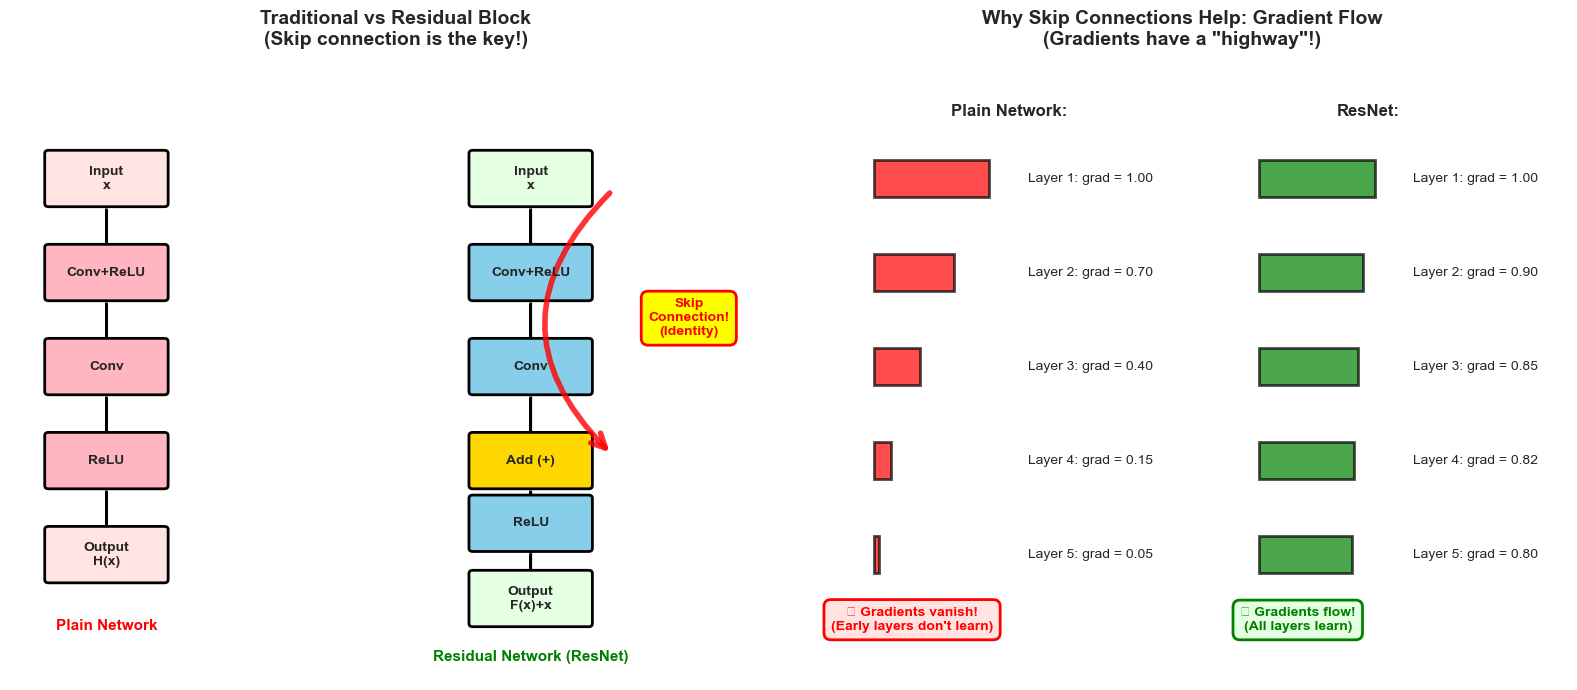


🎯 Why Skip Connections Are Revolutionary:
Problem: Deep networks had vanishing gradients
  • Gradients get smaller as they backpropagate
  • Early layers receive almost no gradient
  • Network can't learn properly

Solution: Skip connections provide a gradient highway
  • Gradients can flow DIRECTLY through skip connections
  • Even if residual path gradient vanishes, identity path is fine
  • All layers receive usable gradients

Mathematical insight:
  • Traditional: learn H(x) directly (hard)
  • ResNet: learn F(x) = H(x) - x (easier!)
  • Output: F(x) + x
  • If identity is optimal, just learn F(x) = 0


In [9]:
# Visualize ResNet's skip connections

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: Compare plain vs residual block
ax1 = axes[0]
ax1.set_xlim(0, 10)
ax1.set_ylim(0, 10)
ax1.axis('off')
ax1.set_title('Traditional vs Residual Block\n(Skip connection is the key!)', 
             fontsize=14, fontweight='bold')

# Traditional block (left side)
trad_layers = [
    {'name': 'Input\nx', 'y': 8},
    {'name': 'Conv+ReLU', 'y': 6.5},
    {'name': 'Conv', 'y': 5},
    {'name': 'ReLU', 'y': 3.5},
    {'name': 'Output\nH(x)', 'y': 2}
]

for i, layer in enumerate(trad_layers):
    if i == 0 or i == len(trad_layers) - 1:
        color = '#FFE4E1'
    else:
        color = '#FFB6C1'
    
    rect = FancyBboxPatch((0.5, layer['y']-0.4), 1.5, 0.8,
                         boxstyle="round,pad=0.05",
                         facecolor=color, edgecolor='black', linewidth=2)
    ax1.add_patch(rect)
    ax1.text(1.25, layer['y'], layer['name'], ha='center', va='center',
            fontsize=10, fontweight='bold')
    
    if i < len(trad_layers) - 1:
        ax1.arrow(1.25, layer['y']-0.5, 0, -0.8, 
                 head_width=0.15, head_length=0.15, fc='black', ec='black', lw=2)

ax1.text(1.25, 0.8, 'Plain Network', ha='center', fontsize=11, 
        fontweight='bold', color='red')

# Residual block (right side)
res_layers = [
    {'name': 'Input\nx', 'y': 8},
    {'name': 'Conv+ReLU', 'y': 6.5},
    {'name': 'Conv', 'y': 5},
    {'name': 'Add (+)', 'y': 3.5},
    {'name': 'ReLU', 'y': 2.5},
    {'name': 'Output\nF(x)+x', 'y': 1.3}
]

for i, layer in enumerate(res_layers):
    if i == 0 or i == len(res_layers) - 1:
        color = '#E4FFE1'
    elif i == 3:
        color = '#FFD700'
    else:
        color = '#87CEEB'
    
    rect = FancyBboxPatch((6, layer['y']-0.4), 1.5, 0.8,
                         boxstyle="round,pad=0.05",
                         facecolor=color, edgecolor='black', linewidth=2)
    ax1.add_patch(rect)
    ax1.text(6.75, layer['y'], layer['name'], ha='center', va='center',
            fontsize=10, fontweight='bold')
    
    if i < len(res_layers) - 1 and i != 2:
        ax1.arrow(6.75, layer['y']-0.5, 0, -0.8, 
                 head_width=0.15, head_length=0.15, fc='black', ec='black', lw=2)
    elif i == 2:
        ax1.arrow(6.75, layer['y']-0.5, 0, -0.8, 
                 head_width=0.15, head_length=0.15, fc='black', ec='black', lw=2)

# Draw skip connection (the magic!)
skip_arrow = FancyArrowPatch((7.8, 7.8), (7.8, 3.6),
                            arrowstyle='->', mutation_scale=25,
                            linewidth=4, color='red', alpha=0.8,
                            connectionstyle="arc3,rad=.5")
ax1.add_patch(skip_arrow)
ax1.text(8.8, 5.5, 'Skip\nConnection!\n(Identity)', ha='center', fontsize=10,
        fontweight='bold', color='red',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', 
                 edgecolor='red', linewidth=2))

ax1.text(6.75, 0.3, 'Residual Network (ResNet)', ha='center', fontsize=11,
        fontweight='bold', color='green')

# Right: Show gradient flow
ax2 = axes[1]
ax2.set_xlim(0, 10)
ax2.set_ylim(0, 10)
ax2.axis('off')
ax2.set_title('Why Skip Connections Help: Gradient Flow\n(Gradients have a "highway"!)', 
             fontsize=14, fontweight='bold')

# Show gradient diminishing in plain network
ax2.text(2, 9, 'Plain Network:', fontsize=12, fontweight='bold')
gradient_values = [1.0, 0.7, 0.4, 0.15, 0.05]
for i, grad in enumerate(gradient_values):
    y = 8 - i * 1.5
    width = grad * 1.5
    rect = Rectangle((1, y-0.3), width, 0.6, facecolor='red', 
                     alpha=0.7, edgecolor='black', linewidth=2)
    ax2.add_patch(rect)
    ax2.text(3, y, f'Layer {i+1}: grad = {grad:.2f}', 
            fontsize=10, va='center')

ax2.text(1.5, 0.8, '❌ Gradients vanish!\n(Early layers don\'t learn)', 
        ha='center', fontsize=10, color='red', fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#FFE4E1', 
                 edgecolor='red', linewidth=2))

# Show gradient maintenance in ResNet
ax2.text(7, 9, 'ResNet:', fontsize=12, fontweight='bold')
gradient_values_res = [1.0, 0.9, 0.85, 0.82, 0.80]
for i, grad in enumerate(gradient_values_res):
    y = 8 - i * 1.5
    width = grad * 1.5
    rect = Rectangle((6, y-0.3), width, 0.6, facecolor='green',
                     alpha=0.7, edgecolor='black', linewidth=2)
    ax2.add_patch(rect)
    ax2.text(8, y, f'Layer {i+1}: grad = {grad:.2f}',
            fontsize=10, va='center')

ax2.text(6.5, 0.8, '✅ Gradients flow!\n(All layers learn)', 
        ha='center', fontsize=10, color='green', fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#E4FFE1',
                 edgecolor='green', linewidth=2))

plt.tight_layout()
plt.show()

print("\n🎯 Why Skip Connections Are Revolutionary:")
print("="*60)
print("Problem: Deep networks had vanishing gradients")
print("  • Gradients get smaller as they backpropagate")
print("  • Early layers receive almost no gradient")
print("  • Network can't learn properly")
print()
print("Solution: Skip connections provide a gradient highway")
print("  • Gradients can flow DIRECTLY through skip connections")
print("  • Even if residual path gradient vanishes, identity path is fine")
print("  • All layers receive usable gradients")
print()
print("Mathematical insight:")
print("  • Traditional: learn H(x) directly (hard)")
print("  • ResNet: learn F(x) = H(x) - x (easier!)")
print("  • Output: F(x) + x")
print("  • If identity is optimal, just learn F(x) = 0")
print("="*60)

---
## 🏆 Superhero Showdown! Who Wins? 🥊

Time for the ultimate battle royale! Let's pit all four legends against each other and see how they stack up!

/var/folders/98/5zng120j50n14r9zjqftvvq00000gn/T/ipykernel_33513/1492123065.py:105: UserWarning: Glyph 128203 (\N{CLIPBOARD}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/var/folders/98/5zng120j50n14r9zjqftvvq00000gn/T/ipykernel_33513/1492123065.py:105: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/var/folders/98/5zng120j50n14r9zjqftvvq00000gn/T/ipykernel_33513/1492123065.py:105: UserWarning: Glyph 127878 (\N{FIREWORKS}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/var/folders/98/5zng120j50n14r9zjqftvvq00000gn/T/ipykernel_33513/1492123065.py:105: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/opt/anaconda3/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128203 (\N{CLIPBOARD}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.11/site-packages/IPyth

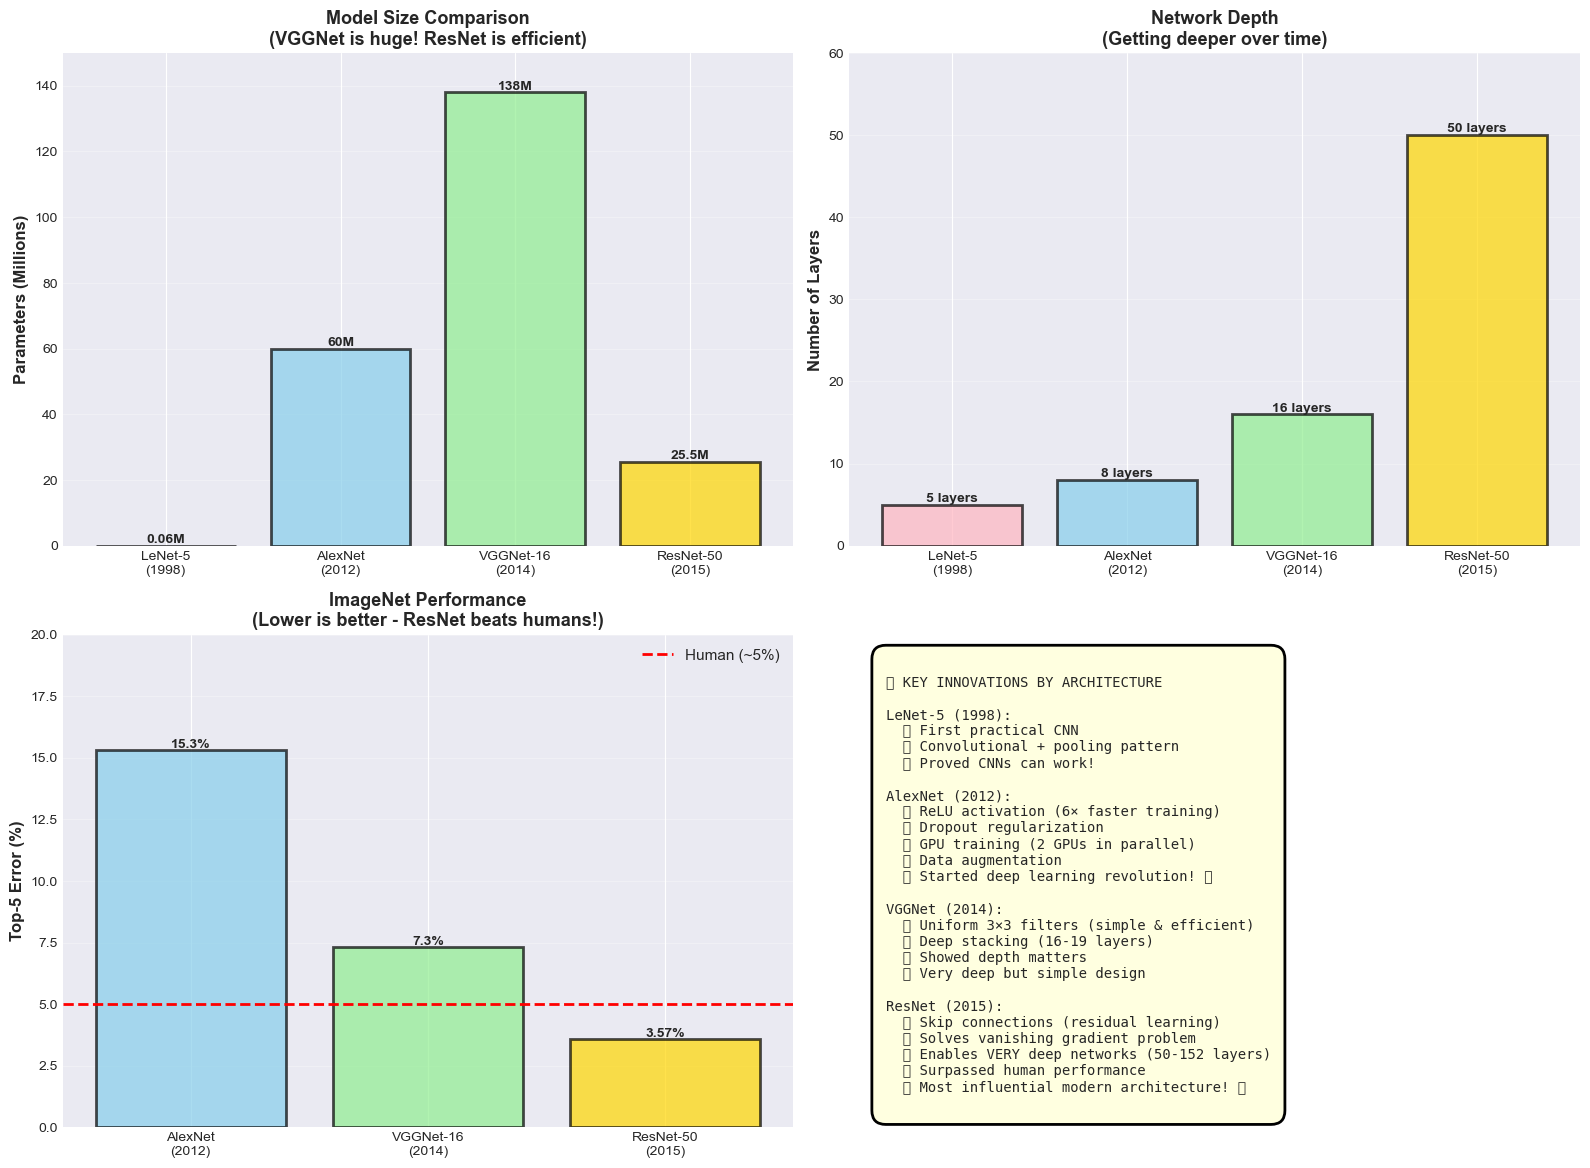


COMPREHENSIVE ARCHITECTURE COMPARISON
Architecture    Year     Depth      Params          Key Innovation                          
LeNet-5         1998     5          60K             First practical CNN                     
AlexNet         2012     8          60M             ReLU, Dropout, GPU training             
VGGNet-16       2014     16         138M            Uniform 3×3 filters, very deep          
ResNet-50       2015     50         25.5M           Skip connections, residual learning     

🎯 Key Trends:
   1. Getting DEEPER: 5 → 8 → 16 → 50 layers
   2. New techniques enable depth: ReLU, skip connections
   3. Efficiency matters: ResNet has fewer params than VGGNet despite being deeper
   4. Each architecture taught us something fundamental

💡 Modern Practice:
   • ResNet is still widely used today (and its variants)
   • Skip connections are now standard in modern architectures
   • VGG's 3×3 filter philosophy influenced many subsequent designs
   • These architectures form 

In [10]:
# Comprehensive comparison of all architectures

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

architectures = ['LeNet-5\n(1998)', 'AlexNet\n(2012)', 'VGGNet-16\n(2014)', 'ResNet-50\n(2015)']
colors = ['#FFB6C1', '#87CEEB', '#90EE90', '#FFD700']

# Plot 1: Parameters (in millions)
ax1 = axes[0, 0]
params = [0.06, 60, 138, 25.5]  # in millions
bars = ax1.bar(architectures, params, color=colors, edgecolor='black', 
              linewidth=2, alpha=0.7)
ax1.set_ylabel('Parameters (Millions)', fontsize=12, fontweight='bold')
ax1.set_title('Model Size Comparison\n(VGGNet is huge! ResNet is efficient)', 
             fontsize=13, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)
ax1.set_ylim(0, 150)

for bar, val in zip(bars, params):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{val}M',
            ha='center', va='bottom', fontweight='bold', fontsize=10)

# Plot 2: Depth (number of layers)
ax2 = axes[0, 1]
depths = [5, 8, 16, 50]
bars = ax2.bar(architectures, depths, color=colors, edgecolor='black',
              linewidth=2, alpha=0.7)
ax2.set_ylabel('Number of Layers', fontsize=12, fontweight='bold')
ax2.set_title('Network Depth\n(Getting deeper over time)', 
             fontsize=13, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)
ax2.set_ylim(0, 60)

for bar, val in zip(bars, depths):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{val} layers',
            ha='center', va='bottom', fontweight='bold', fontsize=10)

# Plot 3: ImageNet Top-5 Error (lower is better)
ax3 = axes[1, 0]
errors = [None, 15.3, 7.3, 3.57]  # LeNet wasn't tested on ImageNet
x_pos = [1, 2, 3]
bars = ax3.bar(x_pos, [errors[1], errors[2], errors[3]], 
              color=[colors[1], colors[2], colors[3]],
              edgecolor='black', linewidth=2, alpha=0.7)
ax3.set_ylabel('Top-5 Error (%)', fontsize=12, fontweight='bold')
ax3.set_title('ImageNet Performance\n(Lower is better - ResNet beats humans!)', 
             fontsize=13, fontweight='bold')
ax3.set_xticks(x_pos)
ax3.set_xticklabels([architectures[1], architectures[2], architectures[3]])
ax3.grid(axis='y', alpha=0.3)
ax3.set_ylim(0, 20)

# Add human performance line
ax3.axhline(y=5, color='red', linestyle='--', linewidth=2, label='Human (~5%)')
ax3.legend(fontsize=11)

for bar, val in zip(bars, [errors[1], errors[2], errors[3]]):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
            f'{val}%',
            ha='center', va='bottom', fontweight='bold', fontsize=10)

# Plot 4: Key Innovation Timeline
ax4 = axes[1, 1]
ax4.axis('off')

innovations_text = """
📋 KEY INNOVATIONS BY ARCHITECTURE

LeNet-5 (1998):
  ✅ First practical CNN
  ✅ Convolutional + pooling pattern
  ✅ Proved CNNs can work!
  
AlexNet (2012):
  ✅ ReLU activation (6× faster training)
  ✅ Dropout regularization
  ✅ GPU training (2 GPUs in parallel)
  ✅ Data augmentation
  ✅ Started deep learning revolution! 🎆
  
VGGNet (2014):
  ✅ Uniform 3×3 filters (simple & efficient)
  ✅ Deep stacking (16-19 layers)
  ✅ Showed depth matters
  ✅ Very deep but simple design
  
ResNet (2015):
  ✅ Skip connections (residual learning)
  ✅ Solves vanishing gradient problem
  ✅ Enables VERY deep networks (50-152 layers)
  ✅ Surpassed human performance
  ✅ Most influential modern architecture! 🏆
"""

ax4.text(0.05, 0.95, innovations_text, transform=ax4.transAxes,
        fontsize=10, verticalalignment='top', family='monospace',
        bbox=dict(boxstyle='round,pad=1', facecolor='lightyellow',
                 edgecolor='black', linewidth=2))

plt.tight_layout()
plt.show()

# Print detailed comparison table
print("\n" + "="*100)
print("COMPREHENSIVE ARCHITECTURE COMPARISON")
print("="*100)
print(f"{'Architecture':<15} {'Year':<8} {'Depth':<10} {'Params':<15} {'Key Innovation':<40}")
print("="*100)

comparisons = [
    ('LeNet-5', '1998', '5', '60K', 'First practical CNN'),
    ('AlexNet', '2012', '8', '60M', 'ReLU, Dropout, GPU training'),
    ('VGGNet-16', '2014', '16', '138M', 'Uniform 3×3 filters, very deep'),
    ('ResNet-50', '2015', '50', '25.5M', 'Skip connections, residual learning'),
]

for arch, year, depth, params, innovation in comparisons:
    print(f"{arch:<15} {year:<8} {depth:<10} {params:<15} {innovation:<40}")

print("="*100)

print("\n🎯 Key Trends:")
print("   1. Getting DEEPER: 5 → 8 → 16 → 50 layers")
print("   2. New techniques enable depth: ReLU, skip connections")
print("   3. Efficiency matters: ResNet has fewer params than VGGNet despite being deeper")
print("   4. Each architecture taught us something fundamental")
print("\n💡 Modern Practice:")
print("   • ResNet is still widely used today (and its variants)")
print("   • Skip connections are now standard in modern architectures")
print("   • VGG's 3×3 filter philosophy influenced many subsequent designs")
print("   • These architectures form the foundation of modern computer vision")

---
## 🎮 Choose Your Fighter!

Which architecture should YOU pick for YOUR project? Let's build a decision guide!

/var/folders/98/5zng120j50n14r9zjqftvvq00000gn/T/ipykernel_33513/1932803896.py:96: UserWarning: Glyph 128218 (\N{BOOKS}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/98/5zng120j50n14r9zjqftvvq00000gn/T/ipykernel_33513/1932803896.py:96: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/98/5zng120j50n14r9zjqftvvq00000gn/T/ipykernel_33513/1932803896.py:96: UserWarning: Glyph 128221 (\N{MEMO}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/98/5zng120j50n14r9zjqftvvq00000gn/T/ipykernel_33513/1932803896.py:96: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/98/5zng120j50n14r9zjqftvvq00000gn/T/ipykernel_33513/1932803896.py:96: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/98/5zng120j50n14r9zjqftvvq00000gn/T/ipykernel_33513/1932803896.py:96: UserWarning: Glyph 128640 (\N{ROCKET}) missing 

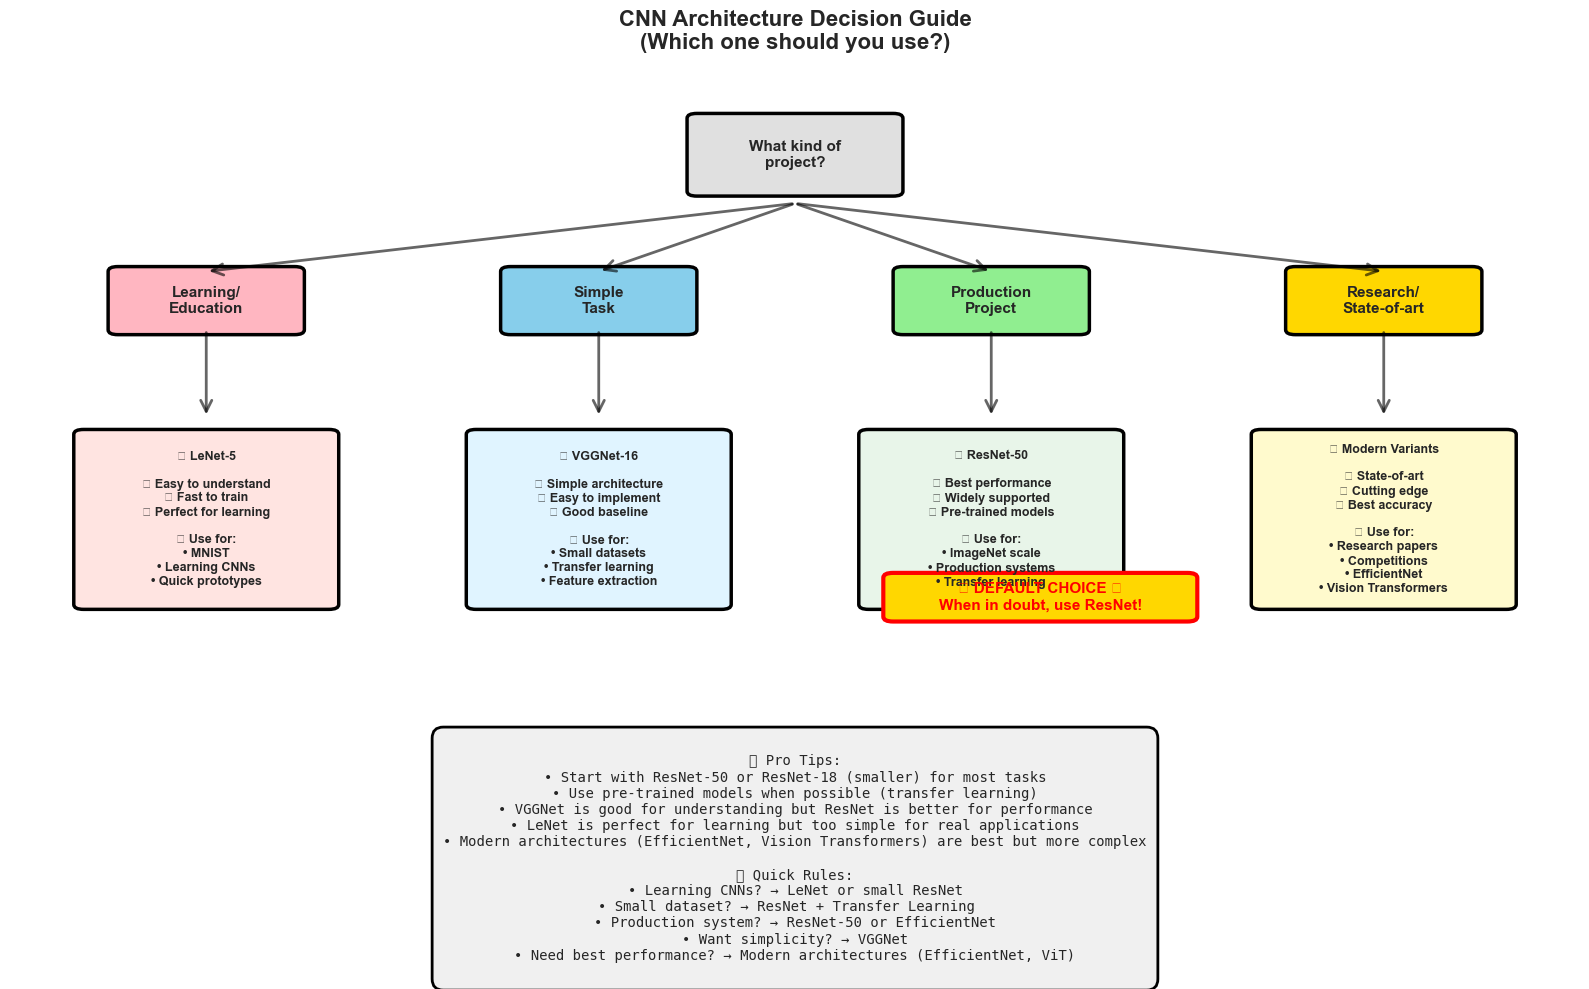


ARCHITECTURE SELECTION GUIDE

📚 FOR LEARNING:
   → LeNet-5: Perfect for understanding CNN basics
   → Build from scratch: Best way to truly understand

🎯 FOR SIMPLE TASKS (MNIST, CIFAR-10):
   → Small ResNet (ResNet-18): Good performance, not too complex
   → VGGNet-16: If you want simplicity over efficiency

🏭 FOR PRODUCTION:
   → ResNet-50: Industry standard, excellent performance
   → EfficientNet: Better accuracy/efficiency trade-off
   → Use pre-trained models and fine-tune

🔬 FOR RESEARCH:
   → Start with ResNet as baseline
   → Experiment with modern architectures
   → Vision Transformers for cutting-edge

💡 GENERAL ADVICE:
   • DON'T start from scratch in production (use pre-trained)
   • DO start from scratch when learning
   • ResNet is a safe default choice for most tasks
   • Consider computational budget (mobile? → EfficientNet)


In [11]:
# Create a decision tree for architecture selection

fig, ax = plt.subplots(figsize=(16, 10))
ax.set_xlim(0, 16)
ax.set_ylim(0, 16)
ax.axis('off')
ax.set_title('CNN Architecture Decision Guide\n(Which one should you use?)', 
             fontsize=16, fontweight='bold')

# Decision nodes
decisions = [
    # Starting point
    {'text': 'What kind of\nproject?', 'x': 8, 'y': 14, 'color': '#E0E0E0', 'size': (2, 1.5)},
    
    # First level
    {'text': 'Learning/\nEducation', 'x': 2, 'y': 11, 'color': '#FFB6C1', 'size': (1.8, 1.2)},
    {'text': 'Simple\nTask', 'x': 6, 'y': 11, 'color': '#87CEEB', 'size': (1.8, 1.2)},
    {'text': 'Production\nProject', 'x': 10, 'y': 11, 'color': '#90EE90', 'size': (1.8, 1.2)},
    {'text': 'Research/\nState-of-art', 'x': 14, 'y': 11, 'color': '#FFD700', 'size': (1.8, 1.2)},
    
    # Recommendations
    {'text': '📚 LeNet-5\n\n✅ Easy to understand\n✅ Fast to train\n✅ Perfect for learning\n\n📝 Use for:\n• MNIST\n• Learning CNNs\n• Quick prototypes', 
     'x': 2, 'y': 6.5, 'color': '#FFE4E1', 'size': (2.5, 3.5)},
    
    {'text': '🎯 VGGNet-16\n\n✅ Simple architecture\n✅ Easy to implement\n✅ Good baseline\n\n📝 Use for:\n• Small datasets\n• Transfer learning\n• Feature extraction', 
     'x': 6, 'y': 6.5, 'color': '#E0F4FF', 'size': (2.5, 3.5)},
    
    {'text': '🏆 ResNet-50\n\n✅ Best performance\n✅ Widely supported\n✅ Pre-trained models\n\n📝 Use for:\n• ImageNet scale\n• Production systems\n• Transfer learning', 
     'x': 10, 'y': 6.5, 'color': '#E8F5E9', 'size': (2.5, 3.5)},
    
    {'text': '🚀 Modern Variants\n\n✅ State-of-art\n✅ Cutting edge\n✅ Best accuracy\n\n📝 Use for:\n• Research papers\n• Competitions\n• EfficientNet\n• Vision Transformers', 
     'x': 14, 'y': 6.5, 'color': '#FFFACD', 'size': (2.5, 3.5)},
]

# Draw decision nodes
for node in decisions:
    rect = FancyBboxPatch((node['x'] - node['size'][0]/2, node['y'] - node['size'][1]/2),
                         node['size'][0], node['size'][1],
                         boxstyle="round,pad=0.1",
                         facecolor=node['color'],
                         edgecolor='black',
                         linewidth=2.5)
    ax.add_patch(rect)
    ax.text(node['x'], node['y'], node['text'],
           ha='center', va='center',
           fontsize=9 if len(node['text']) > 50 else 11,
           fontweight='bold')

# Draw arrows from root to first level
for x_pos in [2, 6, 10, 14]:
    arrow = FancyArrowPatch((8, 13), (x_pos, 11.6),
                           arrowstyle='->', mutation_scale=20,
                           linewidth=2, color='black', alpha=0.6)
    ax.add_patch(arrow)

# Draw arrows from first level to recommendations
arrow_pairs = [(2, 2), (6, 6), (10, 10), (14, 14)]
for from_x, to_x in arrow_pairs:
    arrow = FancyArrowPatch((from_x, 10.4), (to_x, 8.6),
                           arrowstyle='->', mutation_scale=20,
                           linewidth=2, color='black', alpha=0.6)
    ax.add_patch(arrow)

# Add "DEFAULT CHOICE" banner
default_box = FancyBboxPatch((9, 4.5), 3, 0.8,
                            boxstyle="round,pad=0.1",
                            facecolor='#FFD700',
                            edgecolor='red',
                            linewidth=3)
ax.add_patch(default_box)
ax.text(10.5, 4.9, '⭐ DEFAULT CHOICE ⭐\nWhen in doubt, use ResNet!',
       ha='center', va='center', fontsize=11, fontweight='bold', color='red')

# Add bottom notes
notes = """
💡 Pro Tips:
• Start with ResNet-50 or ResNet-18 (smaller) for most tasks
• Use pre-trained models when possible (transfer learning)
• VGGNet is good for understanding but ResNet is better for performance
• LeNet is perfect for learning but too simple for real applications
• Modern architectures (EfficientNet, Vision Transformers) are best but more complex

🎯 Quick Rules:
• Learning CNNs? → LeNet or small ResNet
• Small dataset? → ResNet + Transfer Learning  
• Production system? → ResNet-50 or EfficientNet
• Want simplicity? → VGGNet
• Need best performance? → Modern architectures (EfficientNet, ViT)
"""

ax.text(8, 2, notes, ha='center', va='top',
       fontsize=10, family='monospace',
       bbox=dict(boxstyle='round,pad=0.8', facecolor='#F0F0F0',
                edgecolor='black', linewidth=2))

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("ARCHITECTURE SELECTION GUIDE")
print("="*80)
print()
print("📚 FOR LEARNING:")
print("   → LeNet-5: Perfect for understanding CNN basics")
print("   → Build from scratch: Best way to truly understand")
print()
print("🎯 FOR SIMPLE TASKS (MNIST, CIFAR-10):")
print("   → Small ResNet (ResNet-18): Good performance, not too complex")
print("   → VGGNet-16: If you want simplicity over efficiency")
print()
print("🏭 FOR PRODUCTION:")
print("   → ResNet-50: Industry standard, excellent performance")
print("   → EfficientNet: Better accuracy/efficiency trade-off")
print("   → Use pre-trained models and fine-tune")
print()
print("🔬 FOR RESEARCH:")
print("   → Start with ResNet as baseline")
print("   → Experiment with modern architectures")
print("   → Vision Transformers for cutting-edge")
print()
print("💡 GENERAL ADVICE:")
print("   • DON'T start from scratch in production (use pre-trained)")
print("   • DO start from scratch when learning")
print("   • ResNet is a safe default choice for most tasks")
print("   • Consider computational budget (mobile? → EfficientNet)")
print("="*80)

---
## 🦸 You've Met All the Legends! Final Summary

Congratulations, hero! You've completed the CNN Superhero Hall of Fame tour! 🎉🏛️

### ✅ The Roster Recap

**🛡️ LeNet-5 "The Original" (1998)**
- First CNN that actually worked in the real world
- Conv → Pool → Conv → Pool → FC (the pattern that started it all)
- 5 layers, ~60K parameters — small but legendary
- Lesson learned: **CNNs can solve real problems!**

**🤖 AlexNet "The Game Changer" (2012)**
- Started the deep learning revolution with a bang 🎆
- Key innovations: ReLU (6x faster!), Dropout, GPU training, data augmentation
- 8 layers, ~60M parameters — 1000x bigger than LeNet
- Lesson learned: **Scale + new techniques = breakthrough**

**💪 VGGNet "The Simple Giant" (2014)**
- One trick pony: stack 3×3 filters, go DEEP
- Two 3×3 convs = same receptive field as one 5×5, but 28% fewer params + 2x more ReLUs
- 16 layers, ~138M parameters — the Hulk is HEAVY
- Lesson learned: **Small stacked filters beat large single filters**

**🕷️ ResNet "The Genius" (2015)**
- Skip connections = gradient highway → solves vanishing gradients!
- Bottleneck blocks with 1×1 convs for efficiency
- 50–152 layers, ~25.5M parameters — deep AND efficient
- **Beat human performance** (3.57% vs ~5% error)
- Lesson learned: **Shortcuts enable depth. Depth enables everything.**

### 📊 The Evolution at a Glance

```
Depth:       5 → 8 → 16 → 152 layers  🚀 (getting DEEP)
Innovation:  CNN → ReLU/Dropout → 3×3 stacking → Skip connections
Performance: Good → Great → Excellent → SUPERHUMAN 🤖>🧑
Efficiency:  60K → 60M → 138M → 25.5M params (ResNet: deep AND lean!)
```

### 🎯 MEGA Interview Alert! — The Complete Recap 🚨

Here's everything you need to nail CNN architecture questions:

> **Q: Walk me through the evolution of CNN architectures from LeNet to ResNet.**
>
> **A:** (1) **LeNet-5 (1998)** established the Conv-Pool-FC pattern for digit recognition with 5 layers and ~60K params. (2) **AlexNet (2012)** scaled this to ImageNet (1000 classes), introducing ReLU activation (6x faster training than tanh), Dropout regularization, GPU training, and data augmentation. It won ImageNet by a 10.8% margin, launching the deep learning era. (3) **VGGNet (2014)** showed that depth matters by uniformly stacking 3×3 filters to 16–19 layers. Key insight: two 3×3 convs have the same receptive field as one 5×5 but with fewer parameters (18 vs 25) and more non-linearity (2 ReLUs vs 1). (4) **ResNet (2015)** solved the vanishing gradient problem with skip connections (y = F(x) + x), enabling 152-layer networks that beat human performance. Bottleneck blocks use 1×1 convolutions to reduce/expand channels for efficiency.

> **Q: What is the vanishing gradient problem and how is it solved?**
>
> **A:** Gradients shrink exponentially during backpropagation through many layers (chain rule multiplications of values < 1). Early layers receive near-zero gradients and stop learning. Solutions: (1) **ReLU** — gradient is 1 for positive inputs (no shrinkage), helps for medium-depth networks; (2) **Skip connections (ResNet)** — provide a direct gradient path (identity shortcut has gradient = 1), enabling training of 100+ layer networks; (3) **Batch Normalization** — stabilizes activations, preventing gradient explosion/vanishing.

> **Q: Explain skip connections, 1×1 convolutions, and batch normalization.**
>
> **A:** **Skip connections**: Add block input directly to output (y = F(x) + x). Provides gradient highway and makes identity mapping easy to learn. **1×1 convolutions**: Act as channel-wise linear transformations. In bottleneck blocks, they reduce channels (256→64) before expensive 3×3 convs, then expand back (64→256). Saves massive computation. **Batch normalization**: Normalizes activations to zero mean, unit variance per mini-batch (x̂ = (x-μ)/σ), then applies learnable γ,β. Stabilizes training, enables higher learning rates, adds mild regularization.

> **Q: Why are VGG's 3×3 filters better than larger filters?**
>
> **A:** Two 3×3 convs have a 5×5 receptive field but only 18C² params vs 25C² (28% fewer) and 2 ReLUs vs 1. Three 3×3 convs match a 7×7 receptive field with 27C² vs 49C² params (45% fewer) and 3 ReLUs. More non-linearity = more expressive power. Fewer params = less overfitting.

### 🎓 Design Principles — Your Superhero Training Manual

When designing your own CNN:

**✅ DO:**
- Use skip connections for depth (>20 layers) — it's basically free!
- Use 3×3 filters (efficient and effective) — VGG proved this
- Double channels when halving spatial dimensions (64→128→256→512)
- Use ReLU activation (standard choice since AlexNet)
- Add Batch Normalization between layers (stabilizes everything)
- Consider pre-trained models first (transfer learning — next notebook!)

**❌ DON'T:**
- Use large filters (5×5, 7×7) except maybe the first layer
- Make networks deep without skip connections (vanishing gradients!)
- Forget data augmentation (AlexNet's lesson)
- Ignore computational constraints (VGGNet's 138M params lesson)
- Reinvent the wheel — use proven architectures as starting points

### 🚀 What's Next? The Adventure Continues!

You've graduated from the Hall of Fame! But the superhero universe keeps expanding...

**Next Notebook: Transfer Learning** 🔄
- How to use pre-trained superhero networks for YOUR tasks
- Feature extraction vs. fine-tuning (use their powers, add your own!)
- Practical tips for getting amazing results with small datasets

**Beyond This Series:**
- Modern heroes: EfficientNet, Vision Transformers (ViT)
- Object detection: YOLO, Faster R-CNN
- Semantic segmentation: U-Net, DeepLab
- Neural Architecture Search: letting AI design its OWN architectures 🤯

### 📚 The Original Scrolls (Papers Worth Reading!)

- **LeNet-5**: "Gradient-Based Learning Applied to Document Recognition" (1998)
- **AlexNet**: "ImageNet Classification with Deep CNNs" (2012)
- **VGGNet**: "Very Deep Convolutional Networks for Large-Scale Image Recognition" (2014)
- **ResNet**: "Deep Residual Learning for Image Recognition" (2015)

### 🎮 Practice Challenges — Level Up!

1. **Implement a residual block** from scratch (the most important exercise!)
2. **Compare performance** of LeNet vs. ResNet on CIFAR-10
3. **Count parameters** in each architecture (great interview practice)
4. **Visualize learned filters** — what does each layer "see"?
5. **Design your own architecture** using the principles you learned
6. **Use pre-trained models** for a new task (sneak peek at next notebook!)

### 🎉 Achievement Unlocked: CNN Architecture Master!

You now understand the four most influential CNN architectures in history. You know their origin stories, their superpowers, their weaknesses, and most importantly — **why each one matters for interviews and real-world projects**.

**Ready to use these superheroes in practice?** → **[Next: Notebook 06 — Transfer Learning](06_transfer_learning.ipynb)** 🚀

---

*"If I have seen further, it is by standing on the shoulders of giants."* — Isaac Newton

*Every CNN you'll ever use stands on the shoulders of LeNet, AlexNet, VGGNet, and ResNet. Now you know why.* 🦸